

---

**Exercises**

- [Hamlet: "To Re-Train or not to Re-Train?"](#e1)
- [What is it time?](#e2)
- [BrokenAI](#e3)
- [The importance of being stationary](#e4)

In [ ]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.layers import GRU, LSTM
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from statsmodels.tsa.stattools import adfuller


# Models Comparison

Let:
- $L$ = lookback window  
- $d$ = number of regressors  
- $h$ = number of hidden units  

---

### Ridge Regression on a flattened window **(benchmark)**

Input:
$$
x_t = [X_t, X_{t-1}, \dots, X_{t-L+1}] \in \mathbb{R}^{L d}
$$

Model:
$$
y_t = w^\top x_t + b
$$

Number of parameters:
$$
L d + 1 = O(L)
$$

---

### Fully Connected - 1 hidden layer

Model:
$$
x_t \in \mathbb{R}^{L d} \rightarrow h \rightarrow 1
$$

Number of parameters:
$$
(L d \cdot h + h) + (h + 1) = O(Lh^2)
$$

---

### GRU - 1 hidden layer

Input:
$$
X_{t-L+1:t} \in \mathbb{R}^{L \times d}
$$

Number of parameters:
$$
3 \big(dh + h^2 + h\big) + (h + 1) = O(Lh^3)
$$

---

### LSTM - hidden 1 layer

Input:
$$
X_{t-L+1:t} \in \mathbb{R}^{L \times d}
$$

Number of parameters:
$$
4 \big(dh + h^2 + h\big) + (h + 1) = O(Lh^3)
$$


In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.layers import GRU, LSTM
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD, RMSprop


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(mean_squared_error(y_true, y_pred))


def make_sequences(data, lookback, target_col=-1, pad_left=False, pad_value=0.0):
    #inspect_array_like(data)
    data = np.asarray(data, dtype=float)

    if data.ndim != 2:
        raise ValueError("data must be a 2D array")
    if lookback <= 0:
        raise ValueError("lookback must be a positive integer")

    n_rows, n_features = data.shape
    if target_col < 0:
        target_col = n_features + target_col
    if not (0 <= target_col < n_features):
        raise ValueError("target_col out of bounds")

    X_seq, y_seq = [], []

    if pad_left:
        pad = np.full((lookback - 1, n_features), pad_value, dtype=float)
        padded = np.vstack([pad, data])

        for i in range(n_rows):
            X_seq.append(padded[i:i + lookback, :])
            y_seq.append(data[i, target_col])
    else:
        for i in range(lookback, n_rows):
            X_seq.append(data[i - lookback:i, :])
            y_seq.append(data[i, target_col])

    return np.array(X_seq), np.array(y_seq)


# ============================================================
# Helpers for joint [X, y] transformation
# ============================================================

def _fit_or_apply_joint_transform(
    X,
    y,
    scale=True,
    x_transformer=None,
    fit_x_transformer=True,
):
    """
    Fit/apply a transformer to the joint matrix [X, y].
    """
    X = np.asarray(X, dtype=float)

    if y is None:
        y = np.zeros((len(X), 1), dtype=float)
    else:
        y = np.asarray(y, dtype=float).reshape(-1, 1)

    combined = np.hstack([X, y])

    fitted_transformer = None
    combined_transformed = combined.copy()

    if x_transformer is not None:
        if fit_x_transformer:
            fitted_transformer = clone(x_transformer)
            combined_transformed = fitted_transformer.fit_transform(combined, y)
        else:
            fitted_transformer = x_transformer
            combined_transformed = fitted_transformer.transform(combined)
    elif scale:
        fitted_transformer = StandardScaler()
        combined_transformed = fitted_transformer.fit_transform(combined, y)

    return combined_transformed, fitted_transformer


def _apply_existing_joint_transform(X, y, x_transformer=None):
    """
    Apply an already-fitted transformer to the joint matrix [X, y].
    If y is None, use a placeholder zero column.
    """
    X = np.asarray(X, dtype=float)

    if y is None:
        y = np.zeros((len(X), 1), dtype=float)
    else:
        y = np.asarray(y, dtype=float).reshape(-1, 1)

    combined = np.hstack([X, y])

    if x_transformer is None:
        return combined.copy()

    return x_transformer.transform(combined)

"""
def _inverse_transform_target(y_scaled, x_transformer, n_total_features):
    y_scaled = np.asarray(y_scaled, dtype=float).reshape(-1, 1)
    if x_transformer is None:
        return y_scaled.ravel()

    placeholders = np.zeros((len(y_scaled), n_total_features - 1), dtype=float)
    combined_scaled = np.hstack([placeholders, y_scaled])
    combined_original = x_transformer.inverse_transform(combined_scaled)

    return combined_original[:, -1]
"""

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler


def _find_standard_scalers(transformer):
    """
    Recursively collect all StandardScaler instances inside transformer.
    """
    found = []

    if transformer is None:
        return found

    if isinstance(transformer, StandardScaler):
        return [transformer]

    if isinstance(transformer, Pipeline):
        for _, step in transformer.steps:
            found.extend(_find_standard_scalers(step))
        return found

    if isinstance(transformer, ColumnTransformer):
        items = getattr(transformer, "transformers_", transformer.transformers)
        for _, sub_transformer, _ in items:
            if sub_transformer in ("drop", "passthrough"):
                continue
            found.extend(_find_standard_scalers(sub_transformer))
        return found

    return found


def _inverse_transform_target(y_scaled, x_transformer, n_total_features=None):
    """
    Inverse-transform only the target column, assumed to be the last one.

    Rules:
    - If x_transformer has inverse_transform, try to use it with full-width placeholders
      only if n_total_features is available.
    - Otherwise, recursively search inside Pipeline / ColumnTransformer for a fitted
      StandardScaler.
    - Do NOT assume the scaler was fit on the full dataset width; use scaler.n_features_in_.
    - y is always placed in the last column of the temporary matrix passed to inverse_transform.
    """
    y_scaled = np.asarray(y_scaled, dtype=float).reshape(-1, 1)

    if x_transformer is None:
        return y_scaled.ravel()

    # First try direct inverse_transform only when we know the full width
    if hasattr(x_transformer, "inverse_transform") and n_total_features is not None:
        try:
            placeholders = np.zeros((len(y_scaled), n_total_features - 1), dtype=float)
            combined_scaled = np.hstack([placeholders, y_scaled])
            combined_original = x_transformer.inverse_transform(combined_scaled)
            return np.asarray(combined_original)[:, -1]
        except Exception:
            # Fall back to recursive StandardScaler search
            pass

    scalers = _find_standard_scalers(x_transformer)
    if not scalers:
        raise ValueError(
            "No usable inverse_transform found and no StandardScaler found inside x_transformer."
        )

    # Prefer a scaler whose fitted input width is compatible with putting y in the last column.
    # Since y is assumed to be the last column, any scaler with width >= 1 is structurally usable.
    # To make the choice less arbitrary, prefer the largest fitted width.
    fitted_scalers = [s for s in scalers if hasattr(s, "n_features_in_")]
    if not fitted_scalers:
        raise ValueError(
            "Found StandardScaler instance(s), but none appear to be fitted "
            "(missing n_features_in_)."
        )

    scaler = max(fitted_scalers, key=lambda s: s.n_features_in_)
    width = scaler.n_features_in_

    placeholders = np.zeros((len(y_scaled), width - 1), dtype=float)
    combined_scaled = np.hstack([placeholders, y_scaled])

    combined_original = scaler.inverse_transform(combined_scaled)
    return np.asarray(combined_original)[:, -1]

def _make_optimizer(optimizer, learning_rate):
    if isinstance(optimizer, str):
        name = optimizer.lower()
        if name == "adam":
            return Adam(learning_rate=learning_rate)
        if name == "sgd":
            return SGD(learning_rate=learning_rate)
        if name == "rmsprop":
            return RMSprop(learning_rate=learning_rate)
        raise ValueError(f"Unknown optimizer: {optimizer}")

    try:
        optimizer.learning_rate = learning_rate
    except Exception:
        pass
    return optimizer


# ============================================================
# Ridge
# ============================================================

def train_ridge(
    X,
    y,
    regularization,
    lookback,
    scale=True,
    x_transformer=None,
    fit_x_transformer=True,
):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1, 1)

    train_combined_raw = np.hstack([X, y])

    train_combined_transformed, fitted_transformer = _fit_or_apply_joint_transform(
        X=X,
        y=y,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
    )

    X_seq, y_seq = make_sequences(
        train_combined_transformed,
        lookback=lookback,
        target_col=-1,
        pad_left=False,
    )

    X_seq = X_seq[:, :, :-1]
    X_flat = X_seq.reshape(X_seq.shape[0], -1)

    model = Ridge(alpha=regularization)
    model.fit(X_flat, y_seq.ravel())

    return {
        "model": model,
        "x_transformer": fitted_transformer,
        "lookback": lookback,
        "n_total_features": train_combined_raw.shape[1],
    }


def evaluate_ridge(
    model,
    X,
    y,
    lookback,
    metric,
    x_transformer=None,
    n_total_features=None,
):
    X = np.asarray(X, dtype=float)

    if y is None:
        y_arr = np.zeros((len(X), 1), dtype=float)
        y_available = False
    else:
        y_arr = np.asarray(y, dtype=float).reshape(-1, 1)
        y_available = True

    combined_raw = np.hstack([X, y_arr])

    if x_transformer is not None:
        combined_transformed = x_transformer.transform(combined_raw)
    else:
        combined_transformed = combined_raw.copy()

    X_seq_t, _ = make_sequences(
        combined_transformed,
        lookback=lookback,
        target_col=-1,
        pad_left=True,
    )

    X_seq_t = X_seq_t[:, :, :-1]
    X_flat = X_seq_t.reshape(X_seq_t.shape[0], -1)

    y_pred_scaled = model.predict(X_flat)

    if n_total_features is None:
        n_total_features = combined_raw.shape[1]

    y_pred = _inverse_transform_target(
        y_scaled=y_pred_scaled,
        x_transformer=x_transformer,
        n_total_features=n_total_features,
    )

    if y_available:
        _, y_seq_raw = make_sequences(
            combined_raw,
            lookback=lookback,
            target_col=-1,
            pad_left=True,
        )
        score = metric(y_seq_raw.ravel(), y_pred)
    else:
        y_seq_raw = None
        score = None

    return {
        "metric": score,
        "y_true": None if y_seq_raw is None else y_seq_raw.ravel(),
        "y_pred": y_pred,
    }


# ============================================================
# Feedforward NN
# ============================================================

def train_nn(
    X,
    y,
    lookback,
    n_hidden,
    dropout=0,
    l2_regularization=0,
    optimizer="adam",
    learning_rate=1e-03,
    max_epochs=1000,
    patience=10,
    X_val=None,
    y_val=None,
    scale=True,
    x_transformer=None,
    fit_x_transformer=True,
    batch_size=32,
    verbose=0,
    clipnorm=None,
    clipvalue=None,
):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1, 1)

    train_combined_raw = np.hstack([X, y])

    train_combined_transformed, fitted_transformer = _fit_or_apply_joint_transform(
        X=X,
        y=y,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
    )

    X_train_seq, y_train_seq = make_sequences(
        train_combined_transformed,
        lookback=lookback,
        target_col=-1,
        pad_left=False,
    )

    X_train_seq = X_train_seq[:, :, :-1]
    X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)

    validation_data = None
    monitor = "loss"

    if X_val is not None and y_val is not None:
        X_val = np.asarray(X_val, dtype=float)
        y_val = np.asarray(y_val, dtype=float).reshape(-1, 1)

        val_combined_transformed = _apply_existing_joint_transform(
            X=X_val,
            y=y_val,
            x_transformer=fitted_transformer,
        )

        X_val_seq, y_val_seq = make_sequences(
            val_combined_transformed,
            lookback=lookback,
            target_col=-1,
            pad_left=True,
        )

        X_val_seq = X_val_seq[:, :, :-1]
        X_val_flat = X_val_seq.reshape(X_val_seq.shape[0], -1)

        validation_data = (X_val_flat, y_val_seq.ravel())
        monitor = "val_loss"

    input_dim = X_train_flat.shape[1]

    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(
            n_hidden,
            activation="relu",
            kernel_regularizer=l2(l2_regularization),
        ),
        Dropout(dropout),
        Dense(1),
    ])

    opt = _make_optimizer(optimizer, learning_rate)
    if clipnorm is not None:
        opt.clipnorm = clipnorm
    if clipvalue is not None:
        opt.clipvalue = clipvalue

    model.compile(optimizer=opt, loss="mse")

    early_stopping = EarlyStopping(
        monitor=monitor,
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train_flat,
        y_train_seq.ravel(),
        validation_data=validation_data,
        epochs=max_epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=[early_stopping],
    )

    best_epoch = int(np.argmin(history.history[monitor])) + 1

    return {
        "model": model,
        "x_transformer": fitted_transformer,
        "lookback": lookback,
        "n_total_features": train_combined_raw.shape[1],
        "best_epoch": best_epoch,
        "history": history.history,
        "monitor": monitor,
    }


def evaluate_nn(
    model,
    X,
    y,
    lookback,
    metric,
    x_transformer=None,
    n_total_features=None,
):
    X = np.asarray(X, dtype=float)

    if y is None:
        y_arr = np.zeros((len(X), 1), dtype=float)
        y_available = False
    else:
        y_arr = np.asarray(y, dtype=float).reshape(-1, 1)
        y_available = True

    combined_raw = np.hstack([X, y_arr])

    if x_transformer is not None:
        combined_transformed = x_transformer.transform(combined_raw)
    else:
        combined_transformed = combined_raw.copy()

    X_seq_t, _ = make_sequences(
        combined_transformed,
        lookback=lookback,
        target_col=-1,
        pad_left=True,
    )

    X_seq_t = X_seq_t[:, :, :-1]
    X_flat = X_seq_t.reshape(X_seq_t.shape[0], -1)

    y_pred_scaled = model.predict(X_flat, verbose=0).ravel()

    if n_total_features is None:
        n_total_features = combined_raw.shape[1]

    y_pred = _inverse_transform_target(
        y_scaled=y_pred_scaled,
        x_transformer=x_transformer,
        n_total_features=n_total_features,
    )

    if y_available:
        _, y_seq_raw = make_sequences(
            combined_raw,
            lookback=lookback,
            target_col=-1,
            pad_left=True,
        )
        score = metric(y_seq_raw.ravel(), y_pred)
    else:
        y_seq_raw = None
        score = None

    return {
        "metric": score,
        "y_true": None if y_seq_raw is None else y_seq_raw.ravel(),
        "y_pred": y_pred,
    }


# ============================================================
# GRU
# ============================================================

def train_gru(
    X,
    y,
    lookback,
    n_hidden,
    dropout=0,
    recurrent_dropout=0,
    l2_regularization=None,
    optimizer="adam",
    learning_rate=1e-3,
    max_epochs=1000,
    patience=10,
    X_val=None,
    y_val=None,
    scale=True,
    x_transformer=None,
    fit_x_transformer=True,
    batch_size=32,
    verbose=0,
    clipnorm=None,
    clipvalue=None,
):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1, 1)

    train_combined_raw = np.hstack([X, y])

    train_combined_transformed, fitted_transformer = _fit_or_apply_joint_transform(
        X=X,
        y=y,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
    )

    X_train_seq, y_train_seq = make_sequences(
        train_combined_transformed,
        lookback=lookback,
        target_col=-1,
        pad_left=False,
    )

    X_train_seq = X_train_seq[:, :, :-1]

    validation_data = None
    monitor = "loss"

    if X_val is not None and y_val is not None:
        X_val = np.asarray(X_val, dtype=float)
        y_val = np.asarray(y_val, dtype=float).reshape(-1, 1)

        val_combined_transformed = _apply_existing_joint_transform(
            X=X_val,
            y=y_val,
            x_transformer=fitted_transformer,
        )

        X_val_seq, y_val_seq = make_sequences(
            val_combined_transformed,
            lookback=lookback,
            target_col=-1,
            pad_left=True,
        )

        X_val_seq = X_val_seq[:, :, :-1]
        validation_data = (X_val_seq, y_val_seq.ravel())
        monitor = "val_loss"

    if l2_regularization is None:
        kernel_reg = None
    else:
        if not np.isscalar(l2_regularization):
            raise ValueError("l2_regularization must be either None or a nonnegative number.")
        if l2_regularization < 0:
            raise ValueError("l2_regularization must be nonnegative.")
        kernel_reg = l2(float(l2_regularization))

    model = Sequential([
        Input(shape=(lookback, X_train_seq.shape[2])),
        GRU(
            n_hidden,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=kernel_reg,
        ),
        Dense(1),
    ])

    opt = _make_optimizer(optimizer, learning_rate)
    if clipnorm is not None:
        opt.clipnorm = clipnorm
    if clipvalue is not None:
        opt.clipvalue = clipvalue

    model.compile(optimizer=opt, loss="mse")

    early_stopping = EarlyStopping(
        monitor=monitor,
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train_seq,
        y_train_seq.ravel(),
        validation_data=validation_data,
        epochs=max_epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=[early_stopping],
    )

    best_epoch = int(np.argmin(history.history[monitor])) + 1

    return {
        "model": model,
        "x_transformer": fitted_transformer,
        "lookback": lookback,
        "n_total_features": train_combined_raw.shape[1],
        "best_epoch": best_epoch,
        "history": history.history,
        "monitor": monitor,
    }


def evaluate_gru(
    model,
    X,
    y,
    lookback,
    metric,
    x_transformer=None,
    n_total_features=None,
):
    X = np.asarray(X, dtype=float)

    if y is None:
        y_arr = np.zeros((len(X), 1), dtype=float)
        y_available = False
    else:
        y_arr = np.asarray(y, dtype=float).reshape(-1, 1)
        y_available = True

    combined_raw = np.hstack([X, y_arr])

    if x_transformer is not None:
        combined_transformed = x_transformer.transform(combined_raw)
    else:
        combined_transformed = combined_raw.copy()

    X_seq_t, _ = make_sequences(
        combined_transformed,
        lookback=lookback,
        target_col=-1,
        pad_left=True,
    )

    X_seq_t = X_seq_t[:, :, :-1]
    y_pred_scaled = model.predict(X_seq_t, verbose=0).ravel()

    if n_total_features is None:
        n_total_features = combined_raw.shape[1]

    y_pred = _inverse_transform_target(
        y_scaled=y_pred_scaled,
        x_transformer=x_transformer,
        n_total_features=n_total_features,
    )

    if y_available:
        _, y_seq_raw = make_sequences(
            combined_raw,
            lookback=lookback,
            target_col=-1,
            pad_left=True,
        )
        score = metric(y_seq_raw.ravel(), y_pred)
    else:
        y_seq_raw = None
        score = None

    return {
        "metric": score,
        "y_true": None if y_seq_raw is None else y_seq_raw.ravel(),
        "y_pred": y_pred,
    }


# ============================================================
# LSTM
# ============================================================

def train_lstm(
    X,
    y,
    lookback,
    n_hidden,
    dropout=0,
    recurrent_dropout=0,
    l2_regularization=None,
    optimizer="adam",
    learning_rate=1e-3,
    max_epochs=1000,
    patience=10,
    X_val=None,
    y_val=None,
    scale=True,
    x_transformer=None,
    fit_x_transformer=True,
    batch_size=32,
    verbose=0,
    clipnorm=None,
    clipvalue=None,
):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1, 1)

    train_combined_raw = np.hstack([X, y])

    train_combined_transformed, fitted_transformer = _fit_or_apply_joint_transform(
        X=X,
        y=y,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
    )

    X_train_seq, y_train_seq = make_sequences(
        train_combined_transformed,
        lookback=lookback,
        target_col=-1,
        pad_left=False,
    )

    X_train_seq = X_train_seq[:, :, :-1]

    validation_data = None
    monitor = "loss"

    if X_val is not None and y_val is not None:
        X_val = np.asarray(X_val, dtype=float)
        y_val = np.asarray(y_val, dtype=float).reshape(-1, 1)

        val_combined_transformed = _apply_existing_joint_transform(
            X=X_val,
            y=y_val,
            x_transformer=fitted_transformer,
        )

        X_val_seq, y_val_seq = make_sequences(
            val_combined_transformed,
            lookback=lookback,
            target_col=-1,
            pad_left=True,
        )

        X_val_seq = X_val_seq[:, :, :-1]
        validation_data = (X_val_seq, y_val_seq.ravel())
        monitor = "val_loss"

    if l2_regularization is None:
        kernel_reg = None
    else:
        if not np.isscalar(l2_regularization):
            raise ValueError("l2_regularization must be either None or a nonnegative number.")
        if l2_regularization < 0:
            raise ValueError("l2_regularization must be nonnegative.")
        kernel_reg = l2(float(l2_regularization))

    model = Sequential([
        Input(shape=(lookback, X_train_seq.shape[2])),
        LSTM(
            n_hidden,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=kernel_reg,
        ),
        Dense(1),
    ])

    opt = _make_optimizer(optimizer, learning_rate)
    if clipnorm is not None:
        opt.clipnorm = clipnorm
    if clipvalue is not None:
        opt.clipvalue = clipvalue

    model.compile(optimizer=opt, loss="mse")

    early_stopping = EarlyStopping(
        monitor=monitor,
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train_seq,
        y_train_seq.ravel(),
        validation_data=validation_data,
        epochs=max_epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=[early_stopping],
    )

    best_epoch = int(np.argmin(history.history[monitor])) + 1

    return {
        "model": model,
        "x_transformer": fitted_transformer,
        "lookback": lookback,
        "n_total_features": train_combined_raw.shape[1],
        "best_epoch": best_epoch,
        "history": history.history,
        "monitor": monitor,
    }


def evaluate_lstm(
    model,
    X,
    y,
    lookback,
    metric,
    x_transformer=None,
    n_total_features=None,
):
    X = np.asarray(X, dtype=float)

    if y is None:
        y_arr = np.zeros((len(X), 1), dtype=float)
        y_available = False
    else:
        y_arr = np.asarray(y, dtype=float).reshape(-1, 1)
        y_available = True

    combined_raw = np.hstack([X, y_arr])

    if x_transformer is not None:
        combined_transformed = x_transformer.transform(combined_raw)
    else:
        combined_transformed = combined_raw.copy()

    X_seq_t, _ = make_sequences(
        combined_transformed,
        lookback=lookback,
        target_col=-1,
        pad_left=True,
    )

    X_seq_t = X_seq_t[:, :, :-1]
    y_pred_scaled = model.predict(X_seq_t, verbose=0).ravel()

    if n_total_features is None:
        n_total_features = combined_raw.shape[1]

    y_pred = _inverse_transform_target(
        y_scaled=y_pred_scaled,
        x_transformer=x_transformer,
        n_total_features=n_total_features,
    )

    if y_available:
        _, y_seq_raw = make_sequences(
            combined_raw,
            lookback=lookback,
            target_col=-1,
            pad_left=True,
        )
        score = metric(y_seq_raw.ravel(), y_pred)
    else:
        y_seq_raw = None
        score = None

    return {
        "metric": score,
        "y_true": None if y_seq_raw is None else y_seq_raw.ravel(),
        "y_pred": y_pred,
    }

### Understanding how training instance are made



```
make_sequences(data, lookback, target_col=0, pad_left=True, pad_value=0.0)
```



In [ ]:
X = np.hstack([np.arange(1,7).reshape(-1, 1), -np.arange(1,7).reshape(-1, 1)])
y = np.arange(1,7).reshape(-1, 1)

In [ ]:
X

array([[ 1, -1],
       [ 2, -2],
       [ 3, -3],
       [ 4, -4],
       [ 5, -5],
       [ 6, -6]])

In [ ]:
y

array([[1],
       [2],
       [3],
       [4],
       [5],
       [6]])

In [ ]:
data = np.hstack([y, X])

In [ ]:
data

array([[ 1,  1, -1],
       [ 2,  2, -2],
       [ 3,  3, -3],
       [ 4,  4, -4],
       [ 5,  5, -5],
       [ 6,  6, -6]])

In [ ]:
make_sequences(data, lookback=2, target_col=0)

(array([[[ 1.,  1., -1.],
         [ 2.,  2., -2.]],
 
        [[ 2.,  2., -2.],
         [ 3.,  3., -3.]],
 
        [[ 3.,  3., -3.],
         [ 4.,  4., -4.]],
 
        [[ 4.,  4., -4.],
         [ 5.,  5., -5.]]]),
 array([3., 4., 5., 6.]))

### Library API

The functions also apply the provided `scikit-learn` `Transformer` to the target variable, which is assumed to be the last column of the dataset (this is handled internally whenever needed).

For example, when using `StandardScaler`, the target is standardized as well, and the model predictions are inverse-transformed when necessary.

This is desirable, since the scale of the target can affect the gradient norm and lead to numerical instability.

# Validation

> ⚠ **WARNING**
>
> For time series ensure that `train_test_split(shuffle=False)` to preserve the temporal dimension.

In [ ]:
np.random.seed(0)

n = 300

# ------------------------------------------------------------
# VAR(3) coefficients (must be stable)
# ------------------------------------------------------------
A1 = np.array([
    [0.5, 0.2],
    [0.1, 0.4]
])

A2 = np.array([
    [-0.2, 0.1],
    [0.05, -0.1]
])

A3 = np.array([
    [0.1, 0.0],
    [0.0, 0.1]
])

# ------------------------------------------------------------
# Generate process
# ------------------------------------------------------------
X_full = np.zeros((n, 2))

for t in range(3, n):
    X_full[t] = (
        A1 @ X_full[t-1]
        + A2 @ X_full[t-2]
        + A3 @ X_full[t-3]
        + np.random.normal(scale=0.5, size=2)
    )

df = pd.DataFrame(X_full, columns=["x1", "x2"])

# regressors
X = df.copy()

# ------------------------------------------------------------
# Build target y (depends only on x1, x2)
# ------------------------------------------------------------
noise = np.random.normal(scale=0.1, size=n)

x1 = df["x1"]
x2 = df["x2"]

# lagged features
x1_lag1 = x1.shift(1).fillna(0)
x2_lag2 = x2.shift(2).fillna(0)

# nonlinear + temporal signal
y = (
    # linear
    0.6 * x1
    - 0.4 * x2

    # nonlinear
    + 0.3 * np.tanh(x1)
    + 0.2 * np.sin(2 * x2)

    # interactions
    + 0.4 * x1 * x2

    # temporal dependency (important!)
    + 0.5 * x1_lag1
    - 0.3 * x2_lag2

    # regime switching
    + np.where(x1 > 0, 0.5 * x2, -0.5 * x1)

    # noise
    + noise
)

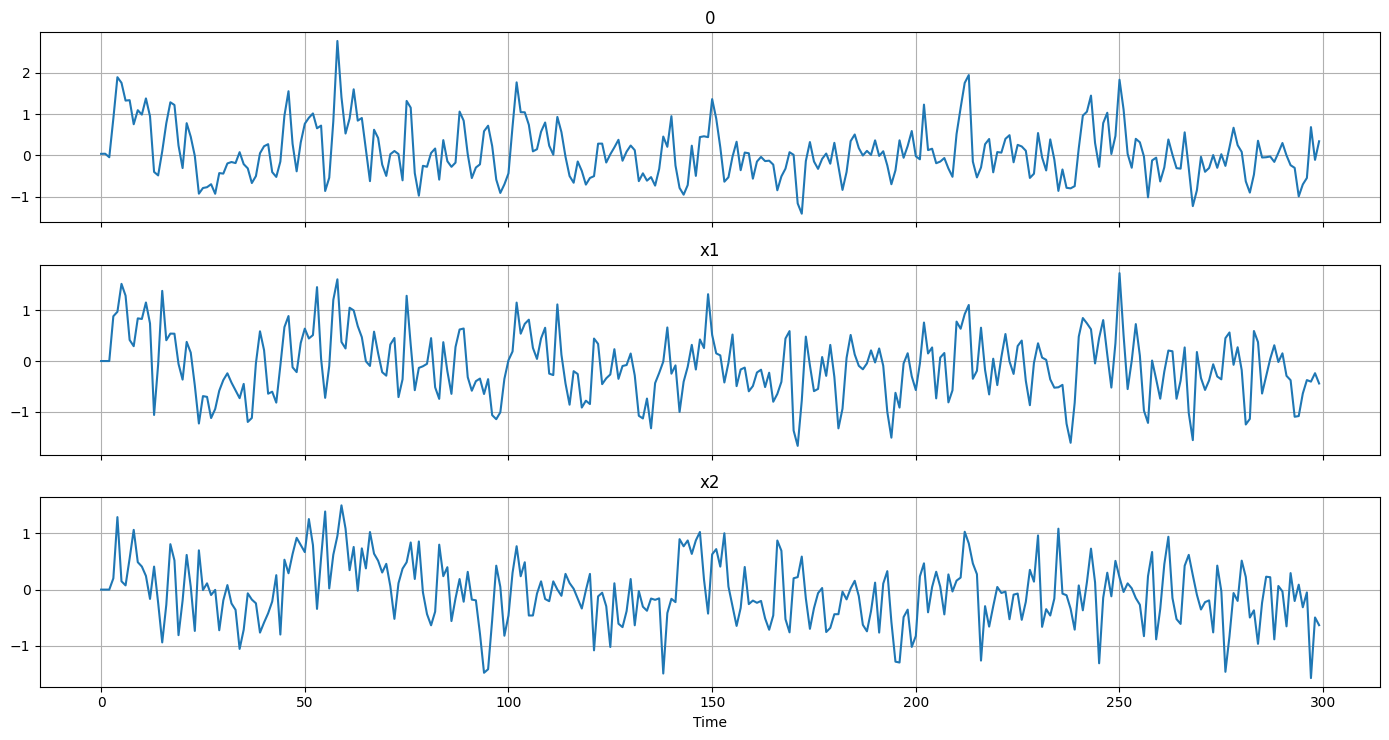

In [ ]:
# ------------------------------------------------------------
# Combine for plotting
# ------------------------------------------------------------
data = pd.concat([y, X], axis=1)

# ------------------------------------------------------------
# Create grid plot (one row per variable)
# ------------------------------------------------------------
n_vars = data.shape[1]

fig, axes = plt.subplots(n_vars, 1, figsize=(14, 2.5 * n_vars), sharex=True)

# If only one variable, make axes iterable
if n_vars == 1:
    axes = [axes]

for i, col in enumerate(data.columns):
    axes[i].plot(data.index, data[col])
    axes[i].set_title(col)
    axes[i].grid(True)

plt.xlabel("Time")
plt.tight_layout()
plt.show()

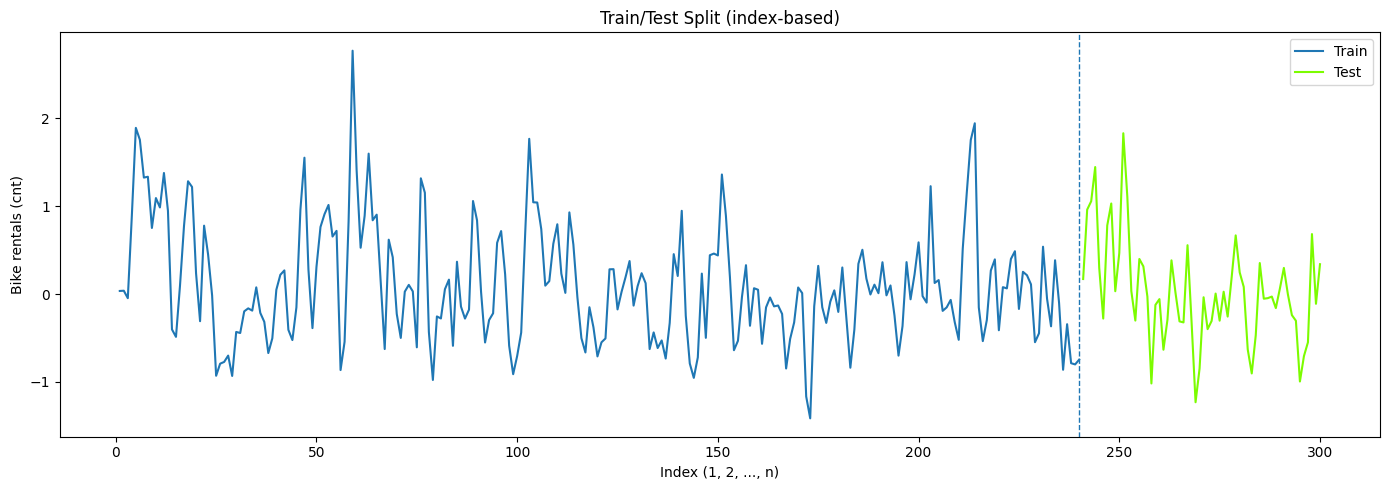

In [ ]:
# ------------------------------------------------------------
# 1) Train/test split (time-aware)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

# ------------------------------------------------------------
# 2) Create integer index (1, 2, ..., n)
# ------------------------------------------------------------
n = len(y)
idx = np.arange(1, n + 1)

# Split indices accordingly
split_point = len(y_train)

idx_train = idx[:split_point]
idx_test = idx[split_point:]

# ------------------------------------------------------------
# 3) Plot
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(idx_train, y_train.values, label="Train")
plt.plot(idx_test, y_test.values, label="Test", color="lawngreen")

# vertical split line
plt.axvline(split_point, linestyle="--", linewidth=1)

plt.title("Train/Test Split (index-based)")
plt.xlabel("Index (1, 2, ..., n)")
plt.ylabel("Bike rentals (cnt)")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:

# ------------------------------------------------------------
# Split train into train + validation
# ------------------------------------------------------------
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,   # 25% of train → validation
    shuffle=False     # 🚨 keep temporal order
)

print("Train (final):", len(y_train_final))
print("Validation:", len(y_val))
print("Test:", len(y_test))

Train (final): 180
Validation: 60
Test: 60


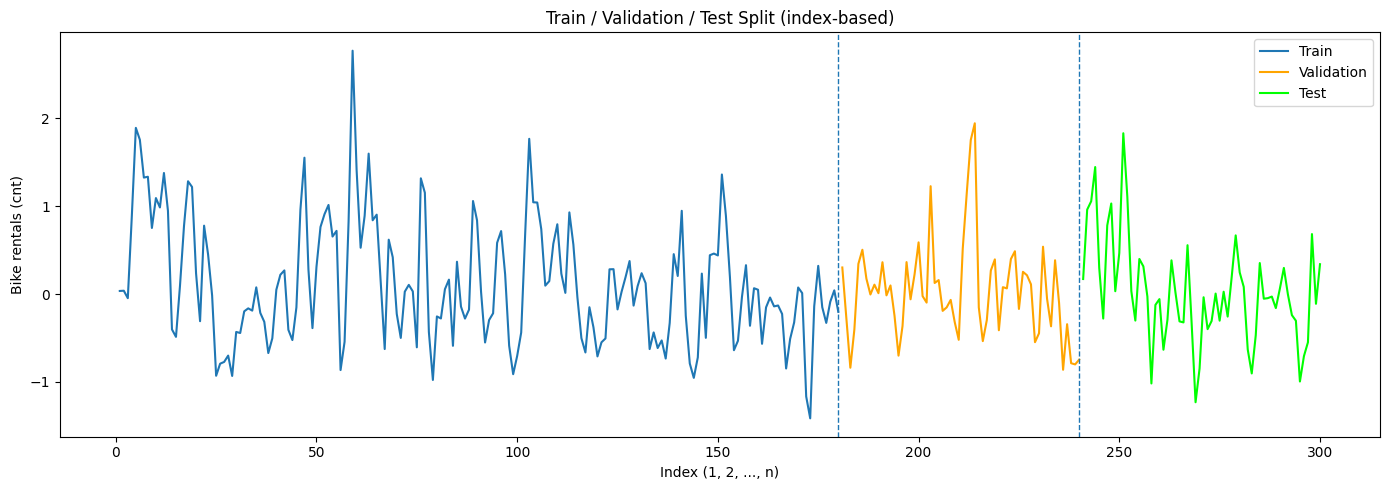

In [ ]:
# full length
n = len(y)
idx = np.arange(1, n + 1)

# boundaries
n_train_final = len(y_train_final)
n_val = len(y_val)

idx_train = idx[:n_train_final]
idx_val = idx[n_train_final:n_train_final + n_val]
idx_test = idx[n_train_final + n_val:]

plt.figure(figsize=(14, 5))

plt.plot(idx_train, y_train_final.values, label="Train")
plt.plot(idx_val, y_val.values, label="Validation", color="orange")
plt.plot(idx_test, y_test.values, label="Test", color="lime")

# vertical split lines
plt.axvline(n_train_final, linestyle="--", linewidth=1)
plt.axvline(n_train_final + n_val, linestyle="--", linewidth=1)

plt.title("Train / Validation / Test Split (index-based)")
plt.xlabel("Index (1, 2, ..., n)")
plt.ylabel("Bike rentals (cnt)")
plt.legend()

plt.tight_layout()
plt.show()

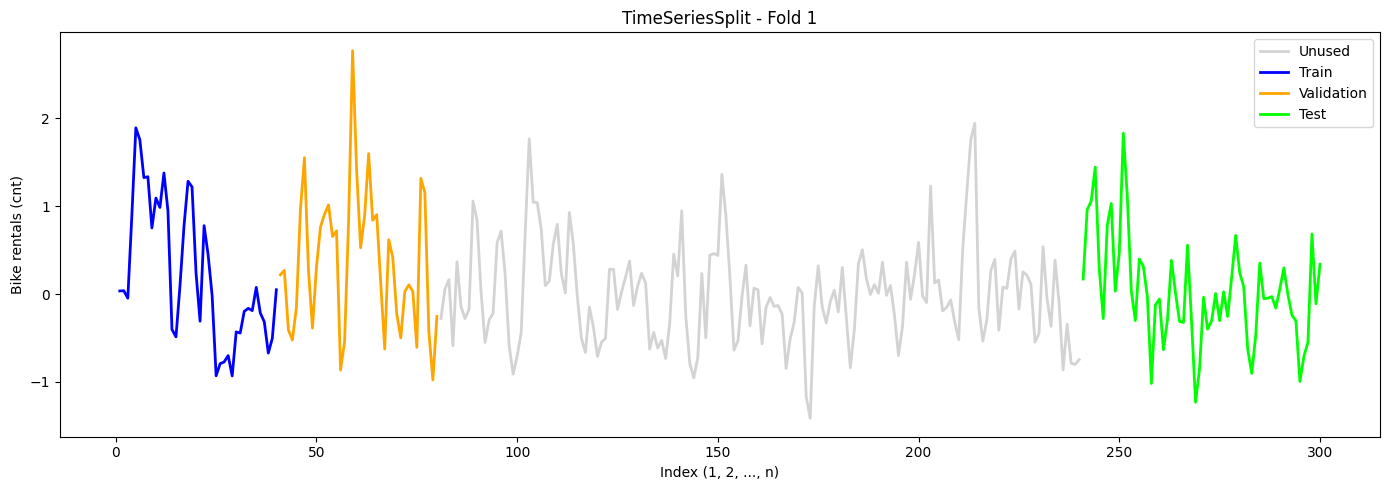

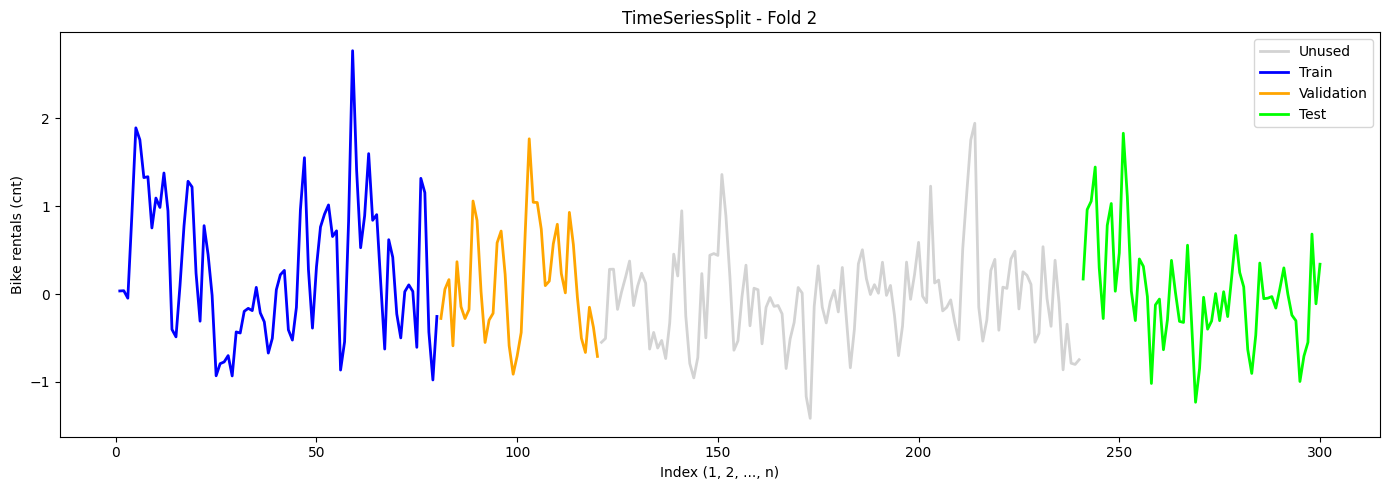

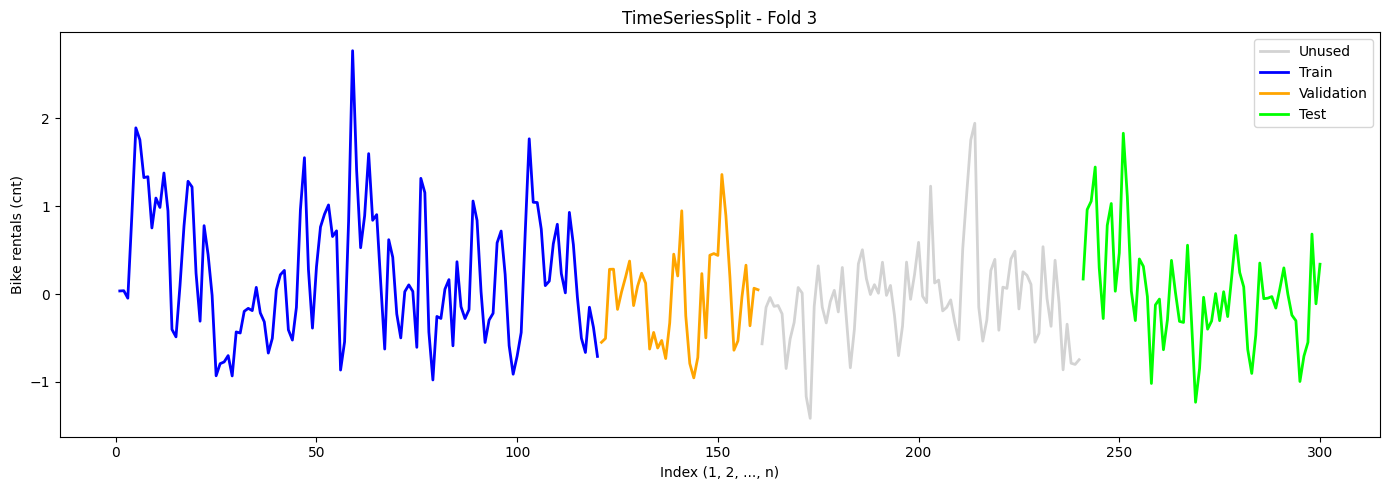

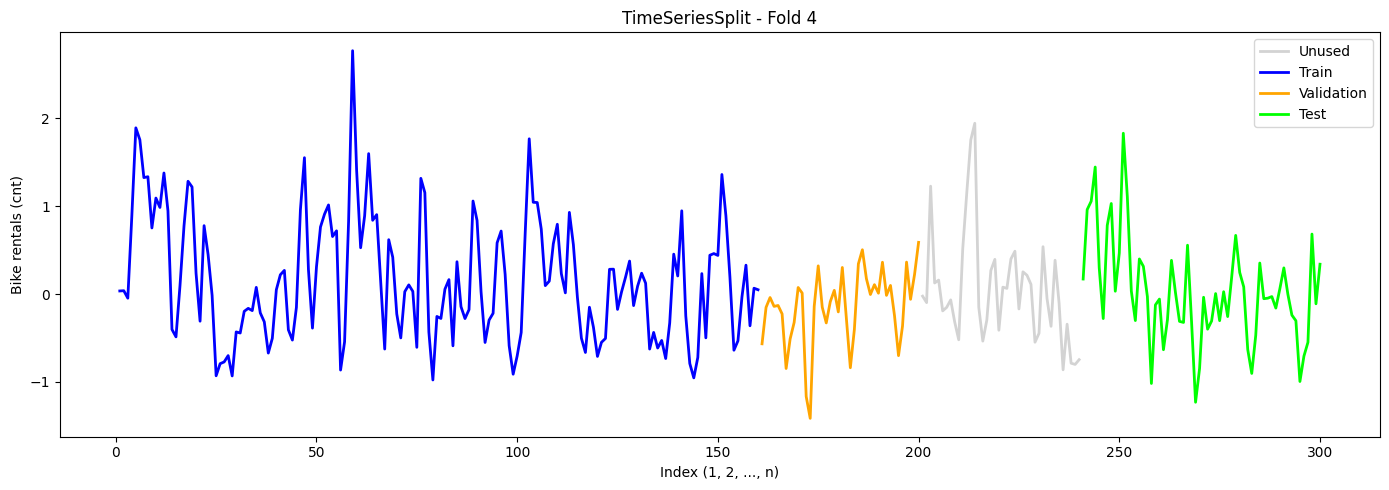

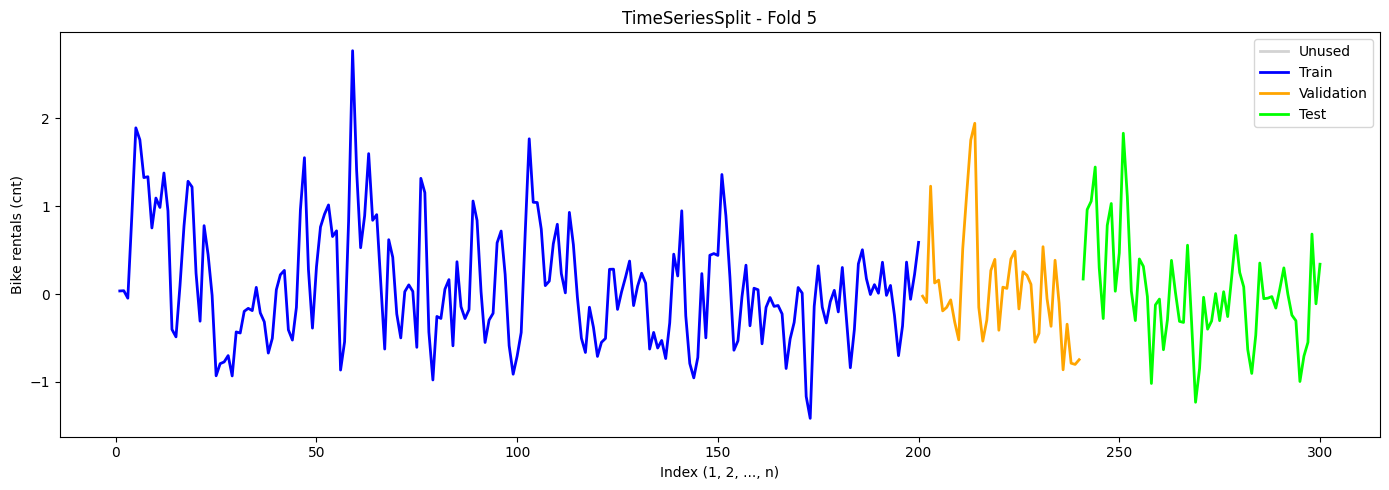

Stored 5 folds in cv_splits


In [ ]:

# ------------------------------------------------------------
# K-fold time series validation on the training set only
# ------------------------------------------------------------
k = 5
tscv = TimeSeriesSplit(n_splits=k)

# Full integer index: 1, 2, ..., n
n_total = len(y)
full_idx = np.arange(1, n_total + 1)

# Lengths and offsets
n_train_total = len(y_train)
n_test = len(y_test)

# Absolute indices of the fixed test set in the full sequence
test_abs_idx = np.arange(n_train_total, n_train_total + n_test)

# Store all splits here
cv_splits = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    # Absolute indices in the full dataset
    train_abs_idx = train_idx
    val_abs_idx = val_idx

    # Store data for later training
    split_data = {
        "fold": fold,
        "X_train": X_train.iloc[train_idx],
        "y_train": y_train.iloc[train_idx],
        "X_val": X_train.iloc[val_idx],
        "y_val": y_train.iloc[val_idx],
        "X_test": X_test,
        "y_test": y_test,
        "train_idx": train_abs_idx,
        "val_idx": val_abs_idx,
        "test_idx": test_abs_idx,
    }
    cv_splits.append(split_data)

    # --------------------------------------------------------
    # Plot this fold
    # lightgrey = not in train / val / test
    # --------------------------------------------------------
    colors = np.array(["lightgrey"] * n_total, dtype=object)
    colors[train_abs_idx] = "blue"
    colors[val_abs_idx] = "orange"
    colors[test_abs_idx] = "lime"

    plt.figure(figsize=(14, 5))

    for color, label in [
        ("lightgrey", "Unused"),
        ("blue", "Train"),
        ("orange", "Validation"),
        ("lime", "Test"),
    ]:
        mask = colors == color
        plt.plot(
            full_idx[mask],
            y.values[mask],
            color=color,
            label=label,
            linewidth=2
        )

    plt.title(f"TimeSeriesSplit - Fold {fold}")
    plt.xlabel("Index (1, 2, ..., n)")
    plt.ylabel("Bike rentals (cnt)")
    plt.legend()
    plt.tight_layout()
    plt.show()

print(f"Stored {len(cv_splits)} folds in cv_splits")

# Examples

### Ridge Regression

In [ ]:
# Parameters
lookback = 4
regularization = 1e-01
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True

ridge_out = train_ridge(
    X=X_train,
    y=y_train,
    regularization=regularization,
    lookback=lookback,
    scale=scale,
    x_transformer=x_transformer,
    fit_x_transformer=fit_x_transformer,
)

ridge_train_eval = evaluate_ridge(
    model=ridge_out["model"],
    X=X_train,
    y=y_train,
    lookback=lookback,
    metric=rmse,
    x_transformer=ridge_out["x_transformer"],
    n_total_features=ridge_out["n_total_features"],
)

ridge_val_eval = evaluate_ridge(
    model=ridge_out["model"],
    X=X_val,
    y=y_val,
    lookback=lookback,
    metric=rmse,
    x_transformer=ridge_out["x_transformer"],
    n_total_features=ridge_out["n_total_features"],
)

ridge_test_eval = evaluate_ridge(
    model=ridge_out["model"],
    X=X_test,
    y=y_test,
    lookback=lookback,
    metric=rmse,
    x_transformer=ridge_out["x_transformer"],
    n_total_features=ridge_out["n_total_features"],
)

ridge_table = pd.DataFrame([{
    "train_RMSE": ridge_train_eval["metric"],
    "val_RMSE": ridge_val_eval["metric"],
    "test_RMSE": ridge_test_eval["metric"],
}])

display(ridge_table.style.format("{:.4f}"))

,train_RMSE,val_RMSE,test_RMSE
0,0.4941,0.4649,0.5141


### NN

In [ ]:


# Parameters
lookback = 4
n_hidden = 16
dropout = 0.0
l2_regularization = 0.0
optimizer = "adam"
learning_rate = 1e-3
max_epochs = 1000
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
batch_size = 16
verbose = 0
clipnorm = None
clipvalue = None

nn_out = train_nn(
    X=X_train,
    y=y_train,
    lookback=lookback,
    n_hidden=n_hidden,
    dropout=dropout,
    l2_regularization=l2_regularization,
    optimizer=optimizer,
    learning_rate=learning_rate,
    max_epochs=max_epochs,
    patience=patience,
    X_val=X_val,
    y_val=y_val,
    scale=scale,
    x_transformer=x_transformer,
    fit_x_transformer=fit_x_transformer,
    batch_size=batch_size,
    verbose=verbose,
    clipnorm=clipnorm,
    clipvalue=clipvalue,
)

nn_train_eval = evaluate_nn(
    model=nn_out["model"],
    X=X_train,
    y=y_train,
    lookback=lookback,
    metric=rmse,
    x_transformer=nn_out["x_transformer"],
    n_total_features=nn_out["n_total_features"],
)

nn_val_eval = evaluate_nn(
    model=nn_out["model"],
    X=X_val,
    y=y_val,
    lookback=lookback,
    metric=rmse,
    x_transformer=nn_out["x_transformer"],
    n_total_features=nn_out["n_total_features"],
)

nn_test_eval = evaluate_nn(
    model=nn_out["model"],
    X=X_test,
    y=y_test,
    lookback=lookback,
    metric=rmse,
    x_transformer=nn_out["x_transformer"],
    n_total_features=nn_out["n_total_features"],
)

nn_table = pd.DataFrame([{
    "train_RMSE": nn_train_eval["metric"],
    "val_RMSE": nn_val_eval["metric"],
    "test_RMSE": nn_test_eval["metric"],
}])

display(nn_table.style.format("{:.4f}"))

,train_RMSE,val_RMSE,test_RMSE
0,0.4340,0.3642,0.4610


### GRU

In [ ]:
# Parameters
lookback = 4
n_hidden = 16
dropout = 0.0
recurrent_dropout = 0.0
l2_regularization = 0.0
optimizer = "adam"
learning_rate = 1e-3
max_epochs = 1000
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
batch_size = 16
verbose = 0
clipnorm = None
clipvalue = None

gru_out = train_gru(
    X=X_train,
    y=y_train,
    lookback=lookback,
    n_hidden=n_hidden,
    dropout=dropout,
    recurrent_dropout=recurrent_dropout,
    l2_regularization=l2_regularization,
    optimizer=optimizer,
    learning_rate=learning_rate,
    max_epochs=max_epochs,
    patience=patience,
    X_val=X_val,
    y_val=y_val,
    scale=scale,
    x_transformer=x_transformer,
    fit_x_transformer=fit_x_transformer,
    batch_size=batch_size,
    verbose=verbose,
    clipnorm=clipnorm,
    clipvalue=clipvalue,
)

gru_train_eval = evaluate_gru(
    model=gru_out["model"],
    X=X_train,
    y=y_train,
    lookback=lookback,
    metric=rmse,
    x_transformer=gru_out["x_transformer"],
    n_total_features=gru_out["n_total_features"],
)

gru_val_eval = evaluate_gru(
    model=gru_out["model"],
    X=X_val,
    y=y_val,
    lookback=lookback,
    metric=rmse,
    x_transformer=gru_out["x_transformer"],
    n_total_features=gru_out["n_total_features"],
)

gru_test_eval = evaluate_gru(
    model=gru_out["model"],
    X=X_test,
    y=y_test,
    lookback=lookback,
    metric=rmse,
    x_transformer=gru_out["x_transformer"],
    n_total_features=gru_out["n_total_features"],
)

gru_table = pd.DataFrame([{
    "train_RMSE": gru_train_eval["metric"],
    "val_RMSE": gru_val_eval["metric"],
    "test_RMSE": gru_test_eval["metric"],
}])

display(gru_table.style.format("{:.4f}"))

,train_RMSE,val_RMSE,test_RMSE
0,0.4092,0.3652,0.3822


### LSTM

In [ ]:
# Parameters
lookback = 4
n_hidden = 16
dropout = 0.0
recurrent_dropout = 0.0
l2_regularization = 0.0
optimizer = "adam"
learning_rate = 1e-3
max_epochs = 1000
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
batch_size = 16
verbose = 0
clipnorm = None
clipvalue = None

lstm_out = train_lstm(
    X=X_train,
    y=y_train,
    lookback=lookback,
    n_hidden=n_hidden,
    dropout=dropout,
    recurrent_dropout=recurrent_dropout,
    l2_regularization=l2_regularization,
    optimizer=optimizer,
    learning_rate=learning_rate,
    max_epochs=max_epochs,
    patience=patience,
    X_val=X_val,
    y_val=y_val,
    scale=scale,
    x_transformer=x_transformer,
    fit_x_transformer=fit_x_transformer,
    batch_size=batch_size,
    verbose=verbose,
    clipnorm=clipnorm,
    clipvalue=clipvalue,
)

lstm_train_eval = evaluate_lstm(
    model=lstm_out["model"],
    X=X_train,
    y=y_train,
    lookback=lookback,
    metric=rmse,
    x_transformer=lstm_out["x_transformer"],
    n_total_features=lstm_out["n_total_features"],
)

lstm_val_eval = evaluate_lstm(
    model=lstm_out["model"],
    X=X_val,
    y=y_val,
    lookback=lookback,
    metric=rmse,
    x_transformer=lstm_out["x_transformer"],
    n_total_features=lstm_out["n_total_features"],
)

lstm_test_eval = evaluate_lstm(
    model=lstm_out["model"],
    X=X_test,
    y=y_test,
    lookback=lookback,
    metric=rmse,
    x_transformer=lstm_out["x_transformer"],
    n_total_features=lstm_out["n_total_features"],
)

lstm_table = pd.DataFrame([{
    "train_RMSE": lstm_train_eval["metric"],
    "val_RMSE": lstm_val_eval["metric"],
    "test_RMSE": lstm_test_eval["metric"],
}])

display(lstm_table.style.format("{:.4f}"))

,train_RMSE,val_RMSE,test_RMSE
0,0.3876,0.3392,0.3595


# Electricity Dataset

We use the **Electricity** dataset from OpenML, which contains observations from the Australian electricity market, with demand, price, and transfer-related variables together with calendar information.

The original data are recorded at a **30-minute frequency** and we consider the following subset of variables:

- $\text{transfer}$: scheduled electricity transfer between New South Wales and Victoria **(target)**,
- $\text{nswdemand}$: electricity demand in New South Wales,
- $\text{vicprice}$: electricity price in Victoria,
- $\text{vicdemand}$: electricity demand in Victoria.

We retain the **last 10'000 observations** of the series.

In [ ]:
from sklearn.datasets import fetch_openml
import pandas as pd

data = fetch_openml("electricity", version=1, as_frame=True)

df = data.frame.copy().tail(8000)
df["vicprice"] = df["vicprice"].clip(-0.1, 0.1)



y = df["transfer"].astype(float)
X = df[["nswdemand", "vicprice", "vicdemand"]].astype(float)
#categorical_cols = ["day", "period", "transfer"]
#continuous_cols = [c for c in X.columns if c not in categorical_cols]

#X[categorical_cols] = X[categorical_cols].astype("category")
#X[continuous_cols] = X[continuous_cols].astype(float)

print(X.shape, y.shape)

(8000, 3) (8000,)


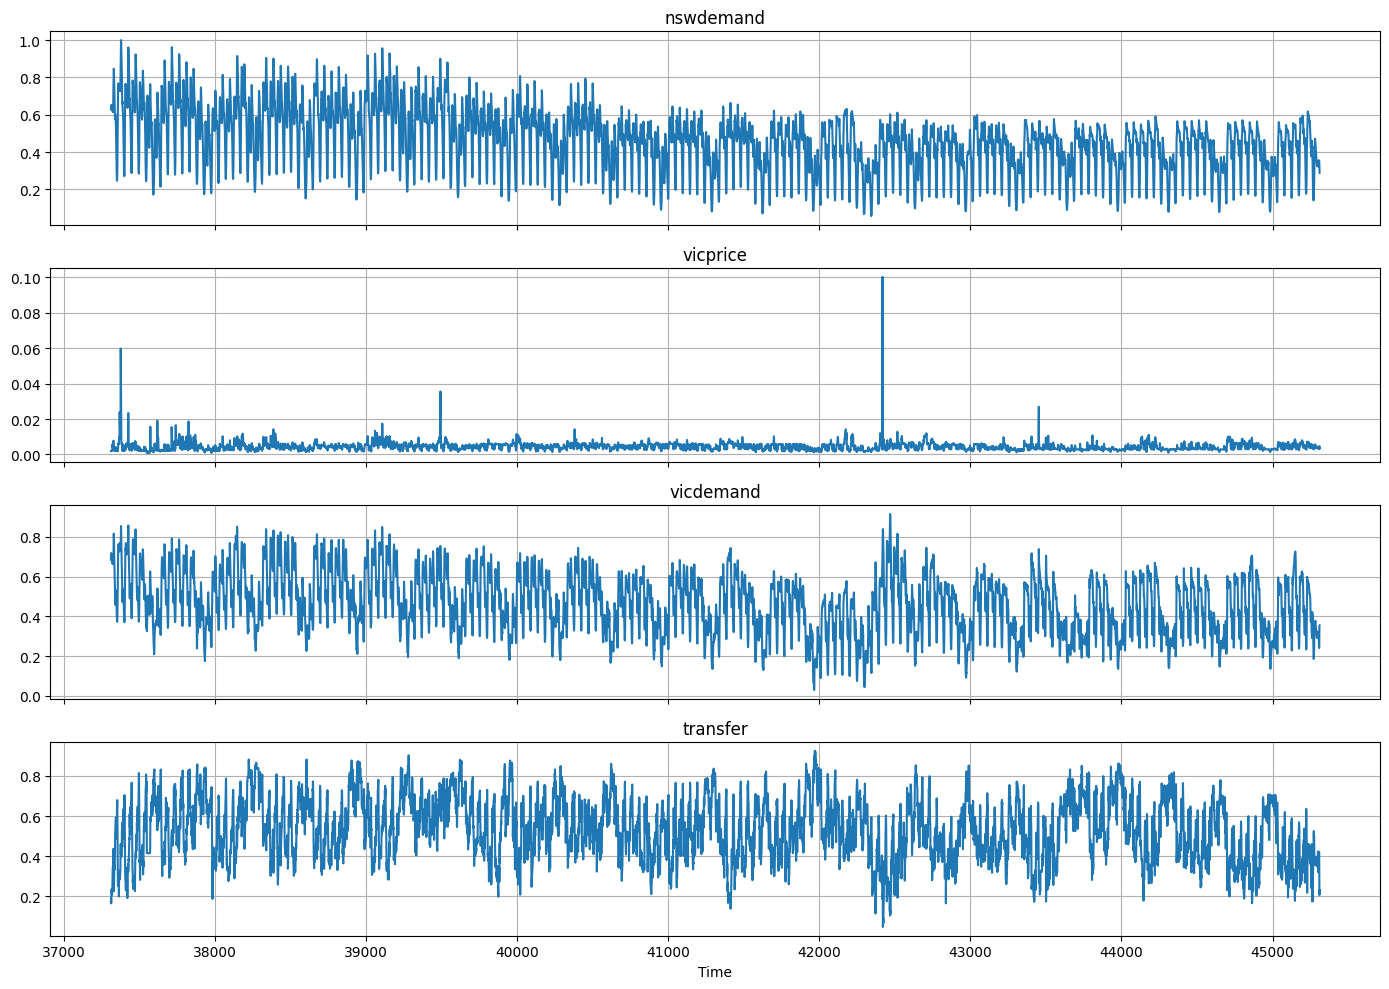

In [ ]:
data = pd.concat([X, y], axis=1)

n_vars = data.shape[1]

fig, axes = plt.subplots(n_vars, 1, figsize=(14, 2.5 * n_vars), sharex=True)

if n_vars == 1:
    axes = [axes]

for i, col in enumerate(data.columns):
    axes[i].plot(data.index, data[col])
    axes[i].set_title(col)
    axes[i].grid(True)

plt.xlabel("Time")
plt.tight_layout()
plt.show()

Train: 4800
Validation: 1600
Test: 1600


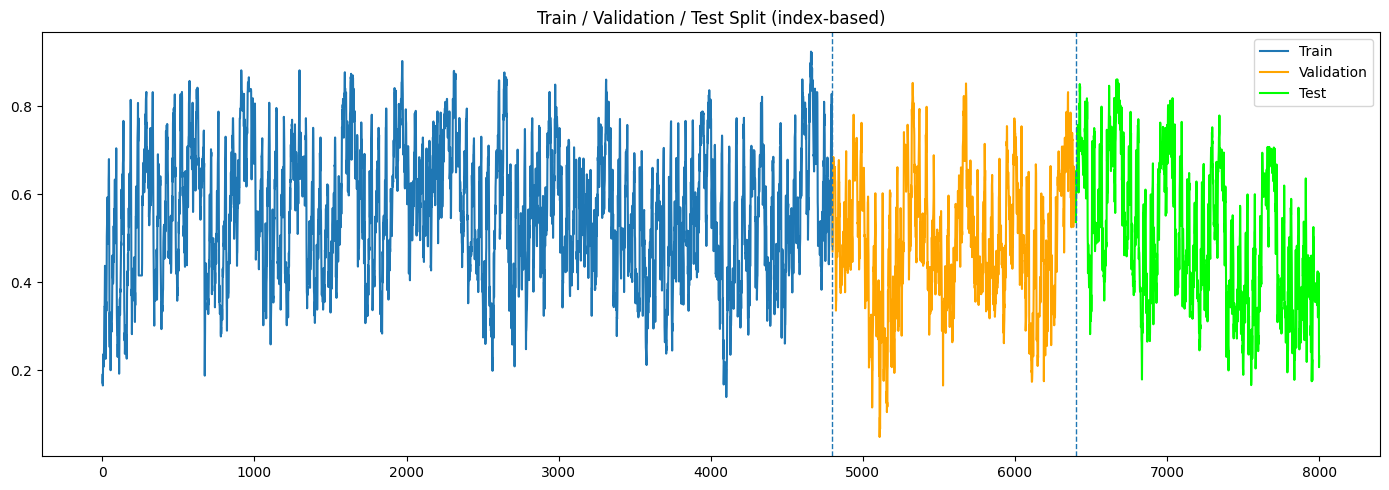

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Train / validation / test split (time-aware)
# ------------------------------------------------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,   # 25% of trainval = 20% of total
    shuffle=False
)

print("Train:", len(y_train))
print("Validation:", len(y_val))
print("Test:", len(y_test))

# ------------------------------------------------------------
# Integer index: 1, 2, ..., n
# ------------------------------------------------------------
n = len(y)
idx = np.arange(1, n + 1)

n_train = len(y_train)
n_val = len(y_val)

idx_train = idx[:n_train]
idx_val = idx[n_train:n_train + n_val]
idx_test = idx[n_train + n_val:]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.plot(idx_train, y_train.values, label="Train")
plt.plot(idx_val, y_val.values, label="Validation", color="orange")
plt.plot(idx_test, y_test.values, label="Test", color="lime")

plt.axvline(n_train, linestyle="--", linewidth=1)
plt.axvline(n_train + n_val, linestyle="--", linewidth=1)

plt.title("Train / Validation / Test Split (index-based)")
plt.legend()

plt.tight_layout()
plt.show()

### Ridge Regression - Validation

In [ ]:

# Fixed parameters

scale = True
x_transformer = StandardScaler()
fit_x_transformer = True

# Grid

lookback_grid = [13, 25, 49]
regularization_grid = [2 * (2 ** k) for k in [0, 2, 4, 6, 8, 10]]

results = []

for lookback in lookback_grid:
    for regularization in regularization_grid:
        print(f"Running lookback={lookback}, regularization={regularization}...")

        ridge_out = train_ridge(
            X=X_train,
            y=y_train,
            regularization=regularization,
            lookback=lookback,
            scale=scale,
            x_transformer=x_transformer,
            fit_x_transformer=fit_x_transformer,
        )

        train_eval = evaluate_ridge(
            model=ridge_out["model"],
            X=X_train,
            y=y_train,
            lookback=lookback,
            metric=rmse,
            x_transformer=ridge_out["x_transformer"],
            n_total_features=ridge_out["n_total_features"],
        )

        val_eval = evaluate_ridge(
            model=ridge_out["model"],
            X=X_val,
            y=y_val,
            lookback=lookback,
            metric=rmse,
            x_transformer=ridge_out["x_transformer"],
            n_total_features=ridge_out["n_total_features"],
        )

        results.append({
            "lookback": lookback,
            "regularization": regularization,
            "train_RMSE": train_eval["metric"],
            "val_RMSE": val_eval["metric"],
        })

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
results_table = (
    pd.DataFrame(results)
    .sort_values(["val_RMSE", "lookback", "regularization"])
    .reset_index(drop=True)
)

display(
    results_table.style.highlight_min(subset=["val_RMSE"], color="lightgreen").format({
        "regularization": "{:.6g}",
        "train_RMSE": "{:.4f}",
        "val_RMSE": "{:.4f}",
    })
)

Running lookback=13, regularization=2...
Running lookback=13, regularization=8...
Running lookback=13, regularization=32...
Running lookback=13, regularization=128...
Running lookback=13, regularization=512...
Running lookback=13, regularization=2048...
Running lookback=25, regularization=2...
Running lookback=25, regularization=8...
Running lookback=25, regularization=32...
Running lookback=25, regularization=128...
Running lookback=25, regularization=512...
Running lookback=25, regularization=2048...
Running lookback=49, regularization=2...
Running lookback=49, regularization=8...
Running lookback=49, regularization=32...
Running lookback=49, regularization=128...
Running lookback=49, regularization=512...
Running lookback=49, regularization=2048...


,lookback,regularization,train_RMSE,val_RMSE
0,49,512,0.0898,0.1081
1,49,128,0.0890,0.1091
2,49,2048,0.0935,0.1093
3,49,32,0.0892,0.1098
4,49,8,0.0896,0.1102
5,49,2,0.0899,0.1104
6,25,128,0.0943,0.1156
7,25,32,0.0940,0.1159
8,25,512,0.0953,0.1161
9,25,8,0.0941,0.1163


### Ridge Regression Re-Train and Test Evaluation

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd



# ------------------------------------------------------------
# Fixed preprocessing parameters
# ------------------------------------------------------------
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True

# ------------------------------------------------------------
# Best parameters (replace with your selected values)
# ------------------------------------------------------------

best_lookback = 49
best_regularization = 512


ridge_out = train_ridge(
    X=X_train,
    y=y_train,
    regularization=best_regularization,
    lookback=best_lookback,
    scale=scale,
    x_transformer=x_transformer,
    fit_x_transformer=fit_x_transformer,
)

train_eval = evaluate_ridge(
    model=ridge_out["model"],
    X=X_train,
    y=y_train,
    lookback=best_lookback,
    metric=rmse,
    x_transformer=ridge_out["x_transformer"],
    n_total_features=ridge_out["n_total_features"],
)

test_eval = evaluate_ridge(
    model=ridge_out["model"],
    X=X_test,
    y=y_test,
    lookback=best_lookback,
    metric=rmse,
    x_transformer=ridge_out["x_transformer"],
    n_total_features=ridge_out["n_total_features"],
)

results_table = pd.DataFrame([{
    "train_RMSE": train_eval["metric"],
    "test_RMSE": test_eval["metric"],
}])

display(
    results_table.style.format({
        "train_RMSE": "{:.4f}",
        "test_RMSE": "{:.4f}",
    })
)

,train_RMSE,test_RMSE
0,0.0898,0.1223


### NN Validation

Running learning_rate=1e-04, l2_regularization=0e+00...
Running learning_rate=1e-04, l2_regularization=1e-05...
Running learning_rate=1e-04, l2_regularization=1e-04...
Running learning_rate=1e-04, l2_regularization=1e-03...
Running learning_rate=1e-04, l2_regularization=1e-02...
Running learning_rate=3e-04, l2_regularization=0e+00...
Running learning_rate=3e-04, l2_regularization=1e-05...
Running learning_rate=3e-04, l2_regularization=1e-04...
Running learning_rate=3e-04, l2_regularization=1e-03...
Running learning_rate=3e-04, l2_regularization=1e-02...
Running learning_rate=1e-03, l2_regularization=0e+00...
Running learning_rate=1e-03, l2_regularization=1e-05...
Running learning_rate=1e-03, l2_regularization=1e-04...
Running learning_rate=1e-03, l2_regularization=1e-03...
Running learning_rate=1e-03, l2_regularization=1e-02...
Running learning_rate=3e-03, l2_regularization=0e+00...
Running learning_rate=3e-03, l2_regularization=1e-05...
Running learning_rate=3e-03, l2_regularization=1

,learning_rate,l2_regularization,best_epoch,train_RMSE,val_RMSE
0,3e-03,1e-04,5,0.0818,0.1098
1,1e-03,1e-02,14,0.0823,0.1163
2,3e-03,1e-03,8,0.0920,0.1163
3,3e-03,1e-02,17,0.0761,0.1164
4,3e-03,1e-05,13,0.0827,0.1197
5,3e-03,0e+00,5,0.1016,0.1220
6,1e-03,1e-03,10,0.0824,0.1242
7,1e-04,1e-02,53,0.0752,0.1253
8,3e-04,1e-02,37,0.0720,0.1267
9,1e-03,1e-04,12,0.0735,0.1286


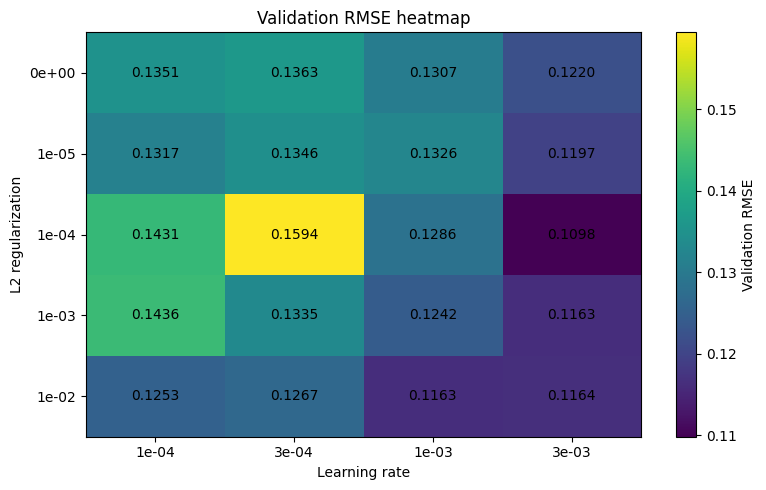

In [ ]:
lookback = 49
n_hidden = 32
dropout = 0.0
optimizer = "rmsprop"
max_epochs = 1000
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
batch_size = 64
verbose = 0
clipnorm = None
clipvalue = None

learning_rate_grid = [1e-4, 3e-4, 1e-3, 3e-3]
l2_regularization_grid = [0.0, 1e-5, 1e-4, 1e-3, 1e-2]

results = []

for learning_rate in learning_rate_grid:
    for l2_regularization in l2_regularization_grid:
        print(
            f"Running learning_rate={learning_rate:.0e}, "
            f"l2_regularization={l2_regularization:.0e}..."
        )

        nn_out = train_nn(
            X=X_train,
            y=y_train,
            lookback=lookback,
            n_hidden=n_hidden,
            dropout=dropout,
            l2_regularization=l2_regularization,
            optimizer=optimizer,
            learning_rate=learning_rate,
            max_epochs=max_epochs,
            patience=patience,
            X_val=X_val,
            y_val=y_val,
            scale=scale,
            x_transformer=x_transformer,
            fit_x_transformer=fit_x_transformer,
            batch_size=batch_size,
            verbose=verbose,
            clipnorm=clipnorm,
            clipvalue=clipvalue,
        )

        train_eval = evaluate_nn(
            model=nn_out["model"],
            X=X_train,
            y=y_train,
            lookback=lookback,
            metric=rmse,
            x_transformer=nn_out["x_transformer"],
            n_total_features=nn_out["n_total_features"],
        )

        val_eval = evaluate_nn(
            model=nn_out["model"],
            X=X_val,
            y=y_val,
            lookback=lookback,
            metric=rmse,
            x_transformer=nn_out["x_transformer"],
            n_total_features=nn_out["n_total_features"],
        )

        results.append({
            "learning_rate": learning_rate,
            "l2_regularization": l2_regularization,
            "best_epoch": nn_out["best_epoch"],
            "train_RMSE": train_eval["metric"],
            "val_RMSE": val_eval["metric"],
        })

results_table = (
    pd.DataFrame(results)
    .sort_values(["val_RMSE", "learning_rate", "l2_regularization"])
    .reset_index(drop=True)
)

display(
    results_table.style.highlight_min(subset=["val_RMSE"], color="lightgreen").format({
        "learning_rate": "{:.0e}",
        "l2_regularization": "{:.0e}",
        "best_epoch": "{:.0f}",
        "train_RMSE": "{:.4f}",
        "val_RMSE": "{:.4f}",
    })
)

heatmap_df = results_table.pivot(
    index="l2_regularization",
    columns="learning_rate",
    values="val_RMSE"
).loc[l2_regularization_grid, learning_rate_grid]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_xticklabels([f"{x:.0e}" for x in heatmap_df.columns])
ax.set_yticklabels([f"{x:.0e}" for x in heatmap_df.index])

ax.set_xlabel("Learning rate")
ax.set_ylabel("L2 regularization")
ax.set_title("Validation RMSE heatmap")

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        ax.text(j, i, f"{value:.4f}", ha="center", va="center")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Validation RMSE")

plt.tight_layout()
plt.show()

<a name="e1"></a>

## Reasoning exercise — Hamlet: "To Re-Train or not to Re-Train?"

If we retrain on the full dataset, we cannot reproduce the validation setting, as we no longer have a validation set for performing early stopping.

If we do not retrain, we discard useful information from the training data and do not make full use of it to achieve the best possible performance on the test set.

What would you do? Keep in mind that there is no theoretical answer to this question in the context of deep learning — it depends on the specific situation.

<details>
<summary>My solution</summary>

My approach, shown in the code below, is to retrain on the full training dataset while performing early stopping directly on the training loss. To avoid overfitting, I fix `max_epochs = best_epoch` ,where both values are estimated from the validation phase.

</details>

In [ ]:
lookback = 49
n_hidden = 32
dropout = 0.0
optimizer = "rmsprop"
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
batch_size = 64
verbose = 0
clipnorm = None
clipvalue = None

max_epochs = 7
learning_rate=3e-03
l2_regularization=1e-04


# ------------------------------------------------------------
# Retrain NN on the whole training dataset
# ------------------------------------------------------------
nn_out = train_nn(
    X=X_train,
    y=y_train,
    lookback=lookback,
    n_hidden=n_hidden,
    dropout=dropout,
    l2_regularization=l2_regularization,
    optimizer=optimizer,
    learning_rate=learning_rate,
    max_epochs=max_epochs,
    patience=patience,
    X_val=None,
    y_val=None,
    scale=scale,
    x_transformer=x_transformer,
    fit_x_transformer=fit_x_transformer,
    batch_size=batch_size,
    verbose=verbose,
    clipnorm=clipnorm,
    clipvalue=clipvalue,
)

# ------------------------------------------------------------
# Evaluate on train
# ------------------------------------------------------------
train_eval = evaluate_nn(
    model=nn_out["model"],
    X=X_train,
    y=y_train,
    lookback=lookback,
    metric=rmse,
    x_transformer=nn_out["x_transformer"],
    n_total_features=nn_out["n_total_features"],
)

# ------------------------------------------------------------
# Evaluate on test
# ------------------------------------------------------------
test_eval = evaluate_nn(
    model=nn_out["model"],
    X=X_test,
    y=y_test,
    lookback=lookback,
    metric=rmse,
    x_transformer=nn_out["x_transformer"],
    n_total_features=nn_out["n_total_features"],
)

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
results_table = pd.DataFrame([{

    "train_RMSE": train_eval["metric"],
    "test_RMSE": test_eval["metric"],
}])

display(
    results_table.style.format({
        "train_RMSE": "{:.4f}",
        "test_RMSE": "{:.4f}",
    })
)

,train_RMSE,test_RMSE
0,0.1142,0.1659


### GRU Validation - Optimizer vs Learning Rate

Running optimizer=adam, learning_rate=0.000050...
Running optimizer=adam, learning_rate=0.000100...
Running optimizer=adam, learning_rate=0.000300...
Running optimizer=adam, learning_rate=0.001000...
Running optimizer=rmsprop, learning_rate=0.000050...
Running optimizer=rmsprop, learning_rate=0.000100...
Running optimizer=rmsprop, learning_rate=0.000300...
Running optimizer=rmsprop, learning_rate=0.001000...


,optimizer,learning_rate,best_epoch,train_RMSE,val_RMSE,time_seconds
0,adam,0.001000,10,0.0770,0.1104,9.86
1,adam,0.000300,9,0.0911,0.1115,8.66
2,rmsprop,0.001000,2,0.0948,0.1154,4.55
3,rmsprop,0.000300,7,0.0915,0.1159,7.06
4,adam,0.000050,35,0.0924,0.1160,22.30
5,adam,0.000100,26,0.0899,0.1161,17.77
6,rmsprop,0.000050,49,0.0888,0.1172,28.46
7,rmsprop,0.000100,19,0.0937,0.1191,13.10


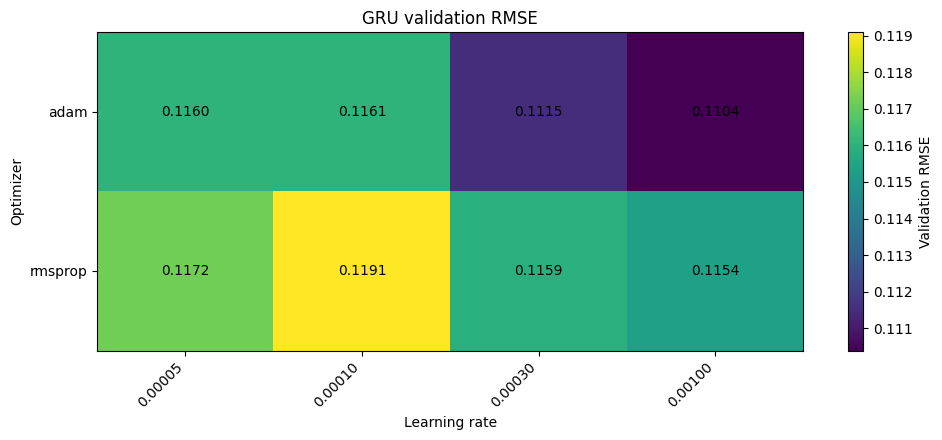

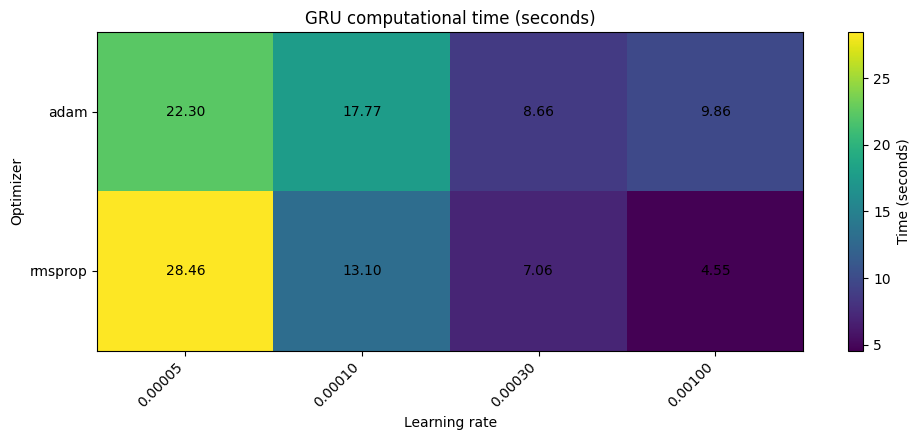

In [ ]:


# Fixed parameters

lookback = 49
n_hidden = 32
dropout = 0.0
optimizer = "rmsprop"
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
batch_size = 64
verbose = 0
clipnorm = None
clipvalue = None

max_epochs = 10000
l2_regularization=1e-04

# Grid

optimizers = ["adam", "rmsprop"]
learning_rates = [5e-5, 1e-4, 3e-4, 1e-3]


results = []


for optimizer in optimizers:
    for learning_rate in learning_rates:
        print(f"Running optimizer={optimizer}, learning_rate={learning_rate:.6f}...")

        start_time = time.perf_counter()

        gru_out = train_gru(
            X=X_train,
            y=y_train,
            lookback=lookback,
            n_hidden=n_hidden,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            l2_regularization=l2_regularization,
            optimizer=optimizer,
            learning_rate=learning_rate,
            max_epochs=max_epochs,
            patience=patience,
            X_val=X_val,
            y_val=y_val,
            scale=scale,
            x_transformer=x_transformer,
            fit_x_transformer=fit_x_transformer,
            batch_size=batch_size,
            verbose=verbose,
            clipnorm=clipnorm,
            clipvalue=clipvalue,
        )

        elapsed_time = time.perf_counter() - start_time

        train_eval = evaluate_gru(
            model=gru_out["model"],
            X=X_train,
            y=y_train,
            lookback=lookback,
            metric=rmse,
            x_transformer=gru_out["x_transformer"],
            n_total_features=gru_out["n_total_features"],
        )

        val_eval = evaluate_gru(
            model=gru_out["model"],
            X=X_val,
            y=y_val,
            lookback=lookback,
            metric=rmse,
            x_transformer=gru_out["x_transformer"],
            n_total_features=gru_out["n_total_features"],
        )

        results.append({
            "optimizer": optimizer,
            "learning_rate": learning_rate,
            "best_epoch": gru_out["best_epoch"],
            "train_RMSE": train_eval["metric"],
            "val_RMSE": val_eval["metric"],
            "time_seconds": elapsed_time,
        })

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
results_table = (
    pd.DataFrame(results)
    .sort_values(["val_RMSE", "optimizer", "learning_rate"])
    .reset_index(drop=True)
)

display(
    results_table.style.highlight_min(subset=["val_RMSE"], color="lightgreen").format({
        "learning_rate": "{:.6f}",
        "best_epoch": "{:.0f}",
        "train_RMSE": "{:.4f}",
        "val_RMSE": "{:.4f}",
        "time_seconds": "{:.2f}",
    })
)

# ------------------------------------------------------------
# Heatmap: validation RMSE
# ------------------------------------------------------------
metric_heatmap_df = results_table.pivot(
    index="optimizer",
    columns="learning_rate",
    values="val_RMSE"
)

metric_heatmap_df = metric_heatmap_df[learning_rates]

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(metric_heatmap_df.values, aspect="auto")

ax.set_xticks(np.arange(len(metric_heatmap_df.columns)))
ax.set_yticks(np.arange(len(metric_heatmap_df.index)))
ax.set_xticklabels([f"{lr:.5f}" for lr in metric_heatmap_df.columns], rotation=45, ha="right")
ax.set_yticklabels(metric_heatmap_df.index)

ax.set_xlabel("Learning rate")
ax.set_ylabel("Optimizer")
ax.set_title("GRU validation RMSE")

for i in range(metric_heatmap_df.shape[0]):
    for j in range(metric_heatmap_df.shape[1]):
        value = metric_heatmap_df.iloc[i, j]
        ax.text(j, i, f"{value:.4f}", ha="center", va="center")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Validation RMSE")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Heatmap: computational time
# ------------------------------------------------------------
time_heatmap_df = results_table.pivot(
    index="optimizer",
    columns="learning_rate",
    values="time_seconds"
)

time_heatmap_df = time_heatmap_df[learning_rates]

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(time_heatmap_df.values, aspect="auto")

ax.set_xticks(np.arange(len(time_heatmap_df.columns)))
ax.set_yticks(np.arange(len(time_heatmap_df.index)))
ax.set_xticklabels([f"{lr:.5f}" for lr in time_heatmap_df.columns], rotation=45, ha="right")
ax.set_yticklabels(time_heatmap_df.index)

ax.set_xlabel("Learning rate")
ax.set_ylabel("Optimizer")
ax.set_title("GRU computational time (seconds)")

for i in range(time_heatmap_df.shape[0]):
    for j in range(time_heatmap_df.shape[1]):
        value = time_heatmap_df.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Time (seconds)")

plt.tight_layout()
plt.show()

Running batch_size=32, learning_rate=0.000300...
Running batch_size=32, learning_rate=0.001000...
Running batch_size=32, learning_rate=0.003000...
Running batch_size=32, learning_rate=0.010000...
Running batch_size=64, learning_rate=0.000300...
Running batch_size=64, learning_rate=0.001000...
Running batch_size=64, learning_rate=0.003000...
Running batch_size=64, learning_rate=0.010000...
Running batch_size=128, learning_rate=0.000300...
Running batch_size=128, learning_rate=0.001000...
Running batch_size=128, learning_rate=0.003000...
Running batch_size=128, learning_rate=0.010000...


,batch_size,learning_rate,best_epoch,train_RMSE,val_RMSE,time_seconds
0,32,0.001000,14,0.0702,0.1044,19.64
1,32,0.003000,2,0.0831,0.1051,8.00
2,64,0.001000,12,0.0730,0.1056,10.31
3,128,0.003000,7,0.0779,0.1059,6.16
4,64,0.003000,5,0.0777,0.1064,6.60
5,32,0.010000,2,0.0779,0.1066,7.97
6,128,0.001000,5,0.0902,0.1082,4.44
7,128,0.010000,4,0.0804,0.1087,4.34
8,64,0.010000,4,0.0714,0.1126,5.95
9,32,0.000300,5,0.0906,0.1134,11.03


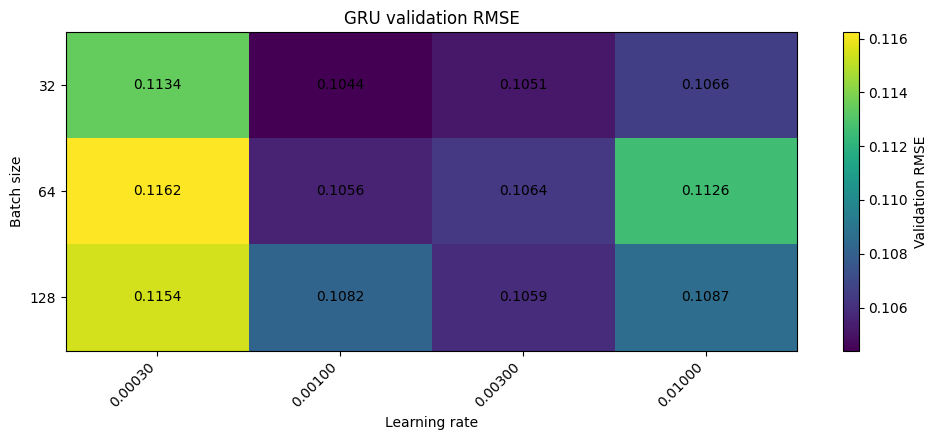

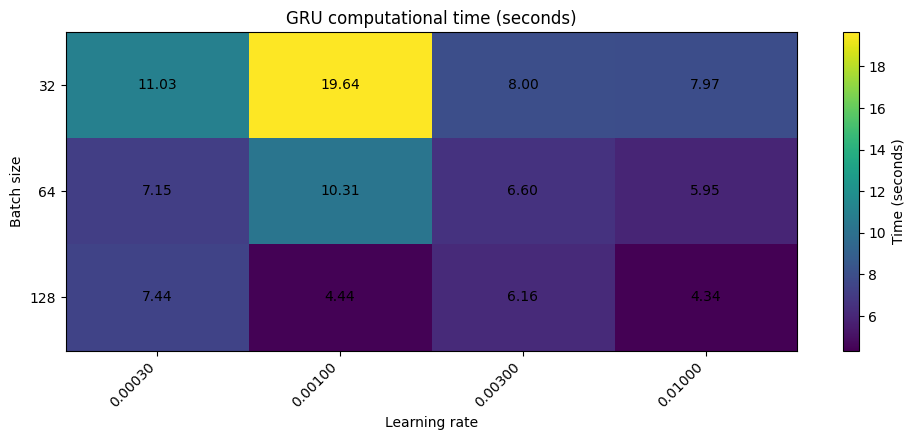

In [ ]:
results = []


# Fixed parameters

lookback = 49
n_hidden = 32
dropout = 0.0
optimizer = "rmsprop"
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
verbose = 0
clipnorm = None
clipvalue = None

max_epochs = 10000
l2_regularization=1e-04
optimizer = "adam"

# Grid

batch_size_grid = [32, 64, 128]
learning_rates = [3e-4, 1e-3, 3e-3, 1e-2]


for batch_size in batch_size_grid:
    for learning_rate in learning_rates:
        print(f"Running batch_size={batch_size}, learning_rate={learning_rate:.6f}...")

        start_time = time.perf_counter()

        gru_out = train_gru(
            X=X_train,
            y=y_train,
            lookback=lookback,
            n_hidden=n_hidden,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            l2_regularization=l2_regularization,
            optimizer=optimizer,
            learning_rate=learning_rate,
            max_epochs=max_epochs,
            patience=patience,
            X_val=X_val,
            y_val=y_val,
            scale=scale,
            x_transformer=x_transformer,
            fit_x_transformer=fit_x_transformer,
            batch_size=batch_size,
            verbose=verbose,
            clipnorm=clipnorm,
            clipvalue=clipvalue,
        )

        elapsed_time = time.perf_counter() - start_time

        train_eval = evaluate_gru(
            model=gru_out["model"],
            X=X_train,
            y=y_train,
            lookback=lookback,
            metric=rmse,
            x_transformer=gru_out["x_transformer"],
            n_total_features=gru_out["n_total_features"],
        )

        val_eval = evaluate_gru(
            model=gru_out["model"],
            X=X_val,
            y=y_val,
            lookback=lookback,
            metric=rmse,
            x_transformer=gru_out["x_transformer"],
            n_total_features=gru_out["n_total_features"],
        )

        results.append({
            "batch_size": batch_size,
            "learning_rate": learning_rate,
            "best_epoch": gru_out["best_epoch"],
            "train_RMSE": train_eval["metric"],
            "val_RMSE": val_eval["metric"],
            "time_seconds": elapsed_time,
        })

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
results_table = (
    pd.DataFrame(results)
    .sort_values(["val_RMSE", "batch_size", "learning_rate"])
    .reset_index(drop=True)
)

display(
    results_table.style.highlight_min(subset=["val_RMSE"], color="lightgreen").format({
        "learning_rate": "{:.6f}",
        "best_epoch": "{:.0f}",
        "train_RMSE": "{:.4f}",
        "val_RMSE": "{:.4f}",
        "time_seconds": "{:.2f}",
    })
)

# ------------------------------------------------------------
# Heatmap: validation RMSE
# ------------------------------------------------------------
metric_heatmap_df = results_table.pivot(
    index="batch_size",
    columns="learning_rate",
    values="val_RMSE"
)

metric_heatmap_df = metric_heatmap_df[learning_rates]

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(metric_heatmap_df.values, aspect="auto")

ax.set_xticks(np.arange(len(metric_heatmap_df.columns)))
ax.set_yticks(np.arange(len(metric_heatmap_df.index)))
ax.set_xticklabels([f"{lr:.5f}" for lr in metric_heatmap_df.columns], rotation=45, ha="right")
ax.set_yticklabels(metric_heatmap_df.index)

ax.set_xlabel("Learning rate")
ax.set_ylabel("Batch size")
ax.set_title("GRU validation RMSE")

for i in range(metric_heatmap_df.shape[0]):
    for j in range(metric_heatmap_df.shape[1]):
        value = metric_heatmap_df.iloc[i, j]
        ax.text(j, i, f"{value:.4f}", ha="center", va="center")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Validation RMSE")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Heatmap: computational time
# ------------------------------------------------------------
time_heatmap_df = results_table.pivot(
    index="batch_size",
    columns="learning_rate",
    values="time_seconds"
)

time_heatmap_df = time_heatmap_df[learning_rates]

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(time_heatmap_df.values, aspect="auto")

ax.set_xticks(np.arange(len(time_heatmap_df.columns)))
ax.set_yticks(np.arange(len(time_heatmap_df.index)))
ax.set_xticklabels([f"{lr:.5f}" for lr in time_heatmap_df.columns], rotation=45, ha="right")
ax.set_yticklabels(time_heatmap_df.index)

ax.set_xlabel("Learning rate")
ax.set_ylabel("Batch size")
ax.set_title("GRU computational time (seconds)")

for i in range(time_heatmap_df.shape[0]):
    for j in range(time_heatmap_df.shape[1]):
        value = time_heatmap_df.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Time (seconds)")

plt.tight_layout()
plt.show()

Running n_hidden=32, dropout=0.0...
Running n_hidden=32, dropout=0.1...
Running n_hidden=32, dropout=0.2...
Running n_hidden=64, dropout=0.0...
Running n_hidden=64, dropout=0.1...
Running n_hidden=64, dropout=0.2...
Running n_hidden=128, dropout=0.0...
Running n_hidden=128, dropout=0.1...
Running n_hidden=128, dropout=0.2...


,n_hidden,dropout,best_epoch,train_RMSE,val_RMSE,time_seconds
0,32,0.0,4,0.0737,0.1037,10.25
1,64,0.0,2,0.0799,0.1049,8.17
2,128,0.2,4,0.0863,0.1064,10.24
3,64,0.2,10,0.0775,0.1081,16.54
4,64,0.1,6,0.0707,0.1116,12.50
5,32,0.2,9,0.0814,0.1118,16.01
6,128,0.0,2,0.0800,0.1126,8.09
7,32,0.1,7,0.0740,0.1190,14.50
8,128,0.1,1,0.0924,0.1208,7.55


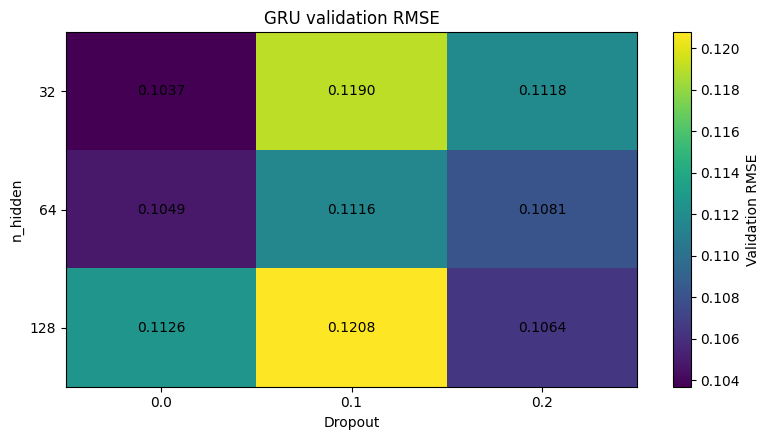

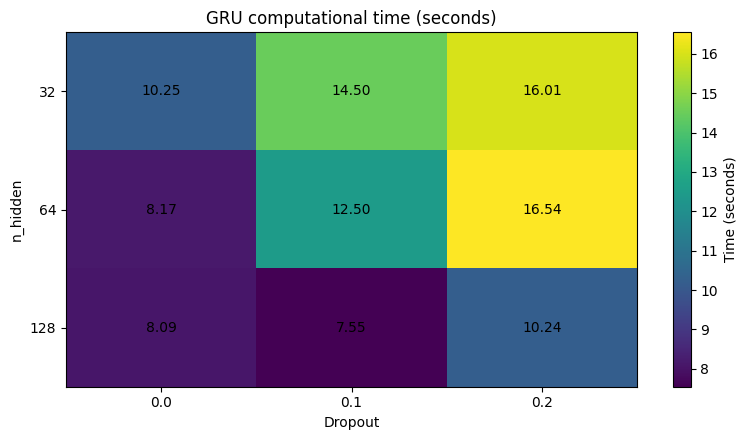

In [ ]:



# Fixed parameters

llookback = 49
optimizer = "rmsprop"
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
verbose = 0
clipnorm = None
clipvalue = None

max_epochs = 10000
l2_regularization=1e-04
optimizer = "adam"

batch_size = 32
learning_rate =  3e-3

# Grid

n_hidden_grid = [32, 64, 128]
dropout_grid = [0.0, 0.1, 0.2]


results = []

for n_hidden in n_hidden_grid:
    for dropout in dropout_grid:
        print(f"Running n_hidden={n_hidden}, dropout={dropout:.1f}...")

        start_time = time.perf_counter()

        gru_out = train_gru(
            X=X_train,
            y=y_train,
            lookback=lookback,
            n_hidden=n_hidden,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            l2_regularization=l2_regularization,
            optimizer=optimizer,
            learning_rate=learning_rate,
            max_epochs=max_epochs,
            patience=patience,
            X_val=X_val,
            y_val=y_val,
            scale=scale,
            x_transformer=x_transformer,
            fit_x_transformer=fit_x_transformer,
            batch_size=batch_size,
            verbose=verbose,
            clipnorm=clipnorm,
            clipvalue=clipvalue,
        )

        elapsed_time = time.perf_counter() - start_time

        train_eval = evaluate_gru(
            model=gru_out["model"],
            X=X_train,
            y=y_train,
            lookback=lookback,
            metric=rmse,
            x_transformer=gru_out["x_transformer"],
            n_total_features=gru_out["n_total_features"],
        )

        val_eval = evaluate_gru(
            model=gru_out["model"],
            X=X_val,
            y=y_val,
            lookback=lookback,
            metric=rmse,
            x_transformer=gru_out["x_transformer"],
            n_total_features=gru_out["n_total_features"],
        )

        results.append({
            "n_hidden": n_hidden,
            "dropout": dropout,
            "best_epoch": gru_out["best_epoch"],
            "train_RMSE": train_eval["metric"],
            "val_RMSE": val_eval["metric"],
            "time_seconds": elapsed_time,
        })

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
results_table = (
    pd.DataFrame(results)
    .sort_values(["val_RMSE", "n_hidden", "dropout"])
    .reset_index(drop=True)
)

display(
    results_table.style.highlight_min(subset=["val_RMSE"], color="lightgreen").format({
        "dropout": "{:.1f}",
        "best_epoch": "{:.0f}",
        "train_RMSE": "{:.4f}",
        "val_RMSE": "{:.4f}",
        "time_seconds": "{:.2f}",
    })
)

# ------------------------------------------------------------
# Heatmap: validation RMSE
# ------------------------------------------------------------
metric_heatmap_df = results_table.pivot(
    index="n_hidden",
    columns="dropout",
    values="val_RMSE"
)

metric_heatmap_df = metric_heatmap_df[dropout_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(metric_heatmap_df.values, aspect="auto")

ax.set_xticks(np.arange(len(metric_heatmap_df.columns)))
ax.set_yticks(np.arange(len(metric_heatmap_df.index)))
ax.set_xticklabels([f"{d:.1f}" for d in metric_heatmap_df.columns])
ax.set_yticklabels(metric_heatmap_df.index)

ax.set_xlabel("Dropout")
ax.set_ylabel("n_hidden")
ax.set_title("GRU validation RMSE")

for i in range(metric_heatmap_df.shape[0]):
    for j in range(metric_heatmap_df.shape[1]):
        value = metric_heatmap_df.iloc[i, j]
        ax.text(j, i, f"{value:.4f}", ha="center", va="center")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Validation RMSE")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Heatmap: computational time
# ------------------------------------------------------------
time_heatmap_df = results_table.pivot(
    index="n_hidden",
    columns="dropout",
    values="time_seconds"
)

time_heatmap_df = time_heatmap_df[dropout_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(time_heatmap_df.values, aspect="auto")

ax.set_xticks(np.arange(len(time_heatmap_df.columns)))
ax.set_yticks(np.arange(len(time_heatmap_df.index)))
ax.set_xticklabels([f"{d:.1f}" for d in time_heatmap_df.columns])
ax.set_yticklabels(time_heatmap_df.index)

ax.set_xlabel("Dropout")
ax.set_ylabel("n_hidden")
ax.set_title("GRU computational time (seconds)")

for i in range(time_heatmap_df.shape[0]):
    for j in range(time_heatmap_df.shape[1]):
        value = time_heatmap_df.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Time (seconds)")

plt.tight_layout()
plt.show()

### GRU - Re-Train and Test Evaluation

In [ ]:
# Fixed parameters

lookback = 49
n_hidden = 32
dropout = 0.0
optimizer = "rmsprop"
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
verbose = 0
clipnorm = None
clipvalue = None

max_epochs = 4
l2_regularization=1e-04
optimizer = "adam"
batch_size=32
learning_rate=0.003


# ------------------------------------------------------------
# Retrain GRU on the full training dataset
# ------------------------------------------------------------
gru_out = train_gru(
    X=X_train,
    y=y_train,
    lookback=lookback,
    n_hidden=n_hidden,
    dropout=dropout,
    recurrent_dropout=recurrent_dropout,
    l2_regularization=l2_regularization,
    optimizer=optimizer,
    learning_rate=learning_rate,
    max_epochs=max_epochs,
    patience=patience,
    X_val=None,
    y_val=None,
    scale=scale,
    x_transformer=x_transformer,
    fit_x_transformer=fit_x_transformer,
    batch_size=batch_size,
    verbose=verbose,
    clipnorm=clipnorm,
    clipvalue=clipvalue,
)

# ------------------------------------------------------------
# Evaluate on train
# ------------------------------------------------------------
train_eval = evaluate_gru(
    model=gru_out["model"],
    X=X_train,
    y=y_train,
    lookback=lookback,
    metric=rmse,
    x_transformer=gru_out["x_transformer"],
    n_total_features=gru_out["n_total_features"],
)

# ------------------------------------------------------------
# Evaluate on test
# ------------------------------------------------------------
test_eval = evaluate_gru(
    model=gru_out["model"],
    X=X_test,
    y=y_test,
    lookback=lookback,
    metric=rmse,
    x_transformer=gru_out["x_transformer"],
    n_total_features=gru_out["n_total_features"],
)

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
results_table = pd.DataFrame([{
    "train_RMSE": train_eval["metric"],
    "test_RMSE": test_eval["metric"],
}])

display(
    results_table.style.format({
        "train_RMSE": "{:.4f}",
        "test_RMSE": "{:.4f}",
    })
)

,train_RMSE,test_RMSE
0,0.0756,0.1146


<a name="e2"></a>

# Exercise — What time is it?

The Electricity dataset also records variables related to time and calendar information:

- $\text{day}$: day of the week,
- $\text{period}$: half-hour period within the day.

These variables are categorical in nature, even if they may be stored numerically. Treating them as ordinary continuous or ordinal variables is not always appropriate, since it introduces an artificial ordering and ignores their cyclical structure.

In particular:

- $\text{day}$ is a general categorical variable,
- $\text{period}$ is a **cyclical categorical** variable, since the last half-hour slot of the day is close to the first one.

There are several possible ways to handle these variables, for example:

- one-hot encoding,
- target encoding,
- positional encoding.

1. You are asked to implement two `scikit-learn` `Transformer`s:

   - one for **target encoding**, to be used as a general method for categorical variables;
   - one for **positional encoding**, to be used specifically for cyclical categorical variables.

   Each transformer must:

   - specify which variables it transforms,
   - implement the `fit` and `transform` methods.

> ⚠ **Warning** These transformations are not invertible. However, for API compatibility, each transformer must still implement an `inverse_transform` method that simply returns the input unchanged. This is not an issue in practice, since we never need to invert these transformations.

2. Using the `scikit-learn` API, combine these transformations appropriately and compare them on the **validation set** with:

   - the baseline case in which nothing is done,
   - one-hot encoding.

   In particular, decide which encoding is appropriate for each variable:
   - use **target encoding** for general categorical variables such as $\text{day}$,
   - use **positional encoding** for cyclical categorical variables such as $\text{period}$,
   - use **one-hot encoding** whenever appropriate.

3. Build and compare different preprocessing combinations for the categorical variables, then select the best preprocessing strategy on the validation set.

4. Finally, evaluate the **best preprocessing combination** on the **test set** for both:

   - the **NN** model,
   - the **GRU** model.

---

### Brief explanation of the methods

#### 1. One-hot encoding
If a variable $x$ can take values in $\{1, \dots, K\}$, one-hot encoding replaces it with a binary vector
$$
e(x) = (e_1(x), \dots, e_K(x)),
$$
where
$$
e_j(x) =
\begin{cases}
1, & \text{if } x = j, \\
0, & \text{otherwise.}
\end{cases}
$$
In this way, categories are treated as distinct binary variables without imposing an order.

#### 2. Target encoding
  
Each category is replaced by the conditional mean of the target for that category.

If $x$ is a categorical variable taking values in $C$, its encoded version is
$$
x \mapsto m(x),
$$
where
$$
m(c) = \mathbb{E}[Y \mid x = c].
$$

In practice, given a training sample, this quantity is estimated by the empirical mean
$$
\hat m(c) = \frac{1}{n_c} \sum_{i:\,x_i=c} y_i,
$$
where $n_c$ is the number of observations such that $x_i=c$.

Thus, each occurrence of category $c$ is replaced by the value $\hat m(c)$.

#### 3. Positional embedding
For cyclical variables, such as hour or month, a more suitable representation is obtained by mapping the variable onto the unit circle. If $x$ has period $P$, then it is transformed into
$$
\left(
\sin\left(2\pi \frac{x}{P}\right),
\cos\left(2\pi \frac{x}{P}\right)
\right).
$$
This encoding preserves the cyclical structure of the variable. For example, hours 23 and 0 are represented as close points, while an ordinal encoding would treat them as far apart.

In [ ]:
from sklearn.datasets import fetch_openml
import pandas as pd

data = fetch_openml("electricity", version=1, as_frame=True)

df = data.frame.copy().tail(8000)
df["vicprice"] = df["vicprice"].clip(-0.1, 0.1)



y = df["transfer"].astype(float)
X = df[['day', 'period', "nswdemand", "vicprice", "vicdemand"]].astype(float)

for col in ["day", "period"]:
    values = np.sort(pd.Series(X[col]).unique())
    mapping = {v: i for i, v in enumerate(values)}
    X[col] = pd.Series(X[col]).map(mapping)

#X["day"] = X["day"].astype(int)
#X["period"] = X["period"].astype(int)

#categorical_cols = ["day", "period", "transfer"]
#continuous_cols = [c for c in X.columns if c not in categorical_cols]

#X[categorical_cols] = X[categorical_cols].astype("category")
#X[continuous_cols] = X[continuous_cols].astype(float)

print(X.shape, y.shape)

(8000, 5) (8000,)


In [ ]:
X.nunique()

,0
day,7
period,48
nswdemand,3651
vicprice,2783
vicdemand,2335


In [ ]:
for c in ['day',   'period']:
  print(c)
  print(X[c].value_counts())

day
day
2    1152
3    1152
4    1152
6    1152
5    1152
1    1136
0    1104
Name: count, dtype: int64
period
period
16    167
17    167
18    167
19    167
20    167
21    167
22    167
23    167
24    167
25    167
26    167
27    167
28    167
29    167
30    167
31    167
32    167
33    167
34    167
35    167
36    167
37    167
38    167
39    167
40    167
41    167
42    167
43    167
44    167
45    167
46    167
47    167
0     166
1     166
2     166
3     166
4     166
5     166
6     166
7     166
8     166
9     166
10    166
11    166
12    166
13    166
14    166
15    166
Name: count, dtype: int64


Train: 4800
Validation: 1600
Test: 1600


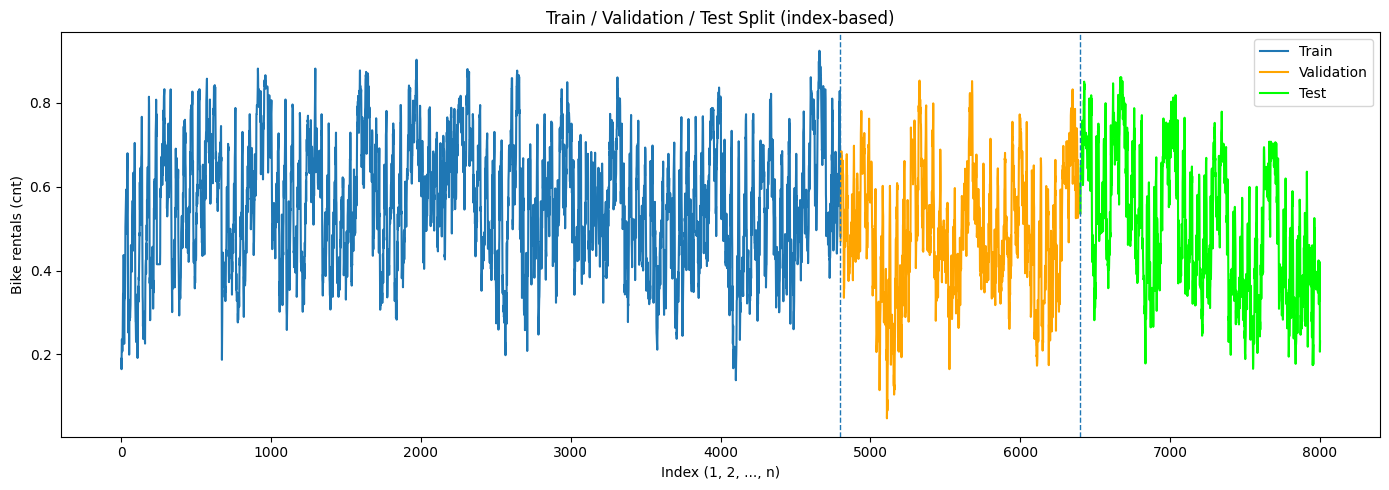

In [ ]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,   # 25% of trainval = 20% of total
    shuffle=False
)



print("Train:", len(y_train))
print("Validation:", len(y_val))
print("Test:", len(y_test))

# ------------------------------------------------------------
# Integer index: 1, 2, ..., n
# ------------------------------------------------------------
n = len(y)
idx = np.arange(1, n + 1)

n_train = len(y_train)
n_val = len(y_val)

idx_train = idx[:n_train]
idx_val = idx[n_train:n_train + n_val]
idx_test = idx[n_train + n_val:]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.plot(idx_train, y_train.values, label="Train")
plt.plot(idx_val, y_val.values, label="Validation", color="orange")
plt.plot(idx_test, y_test.values, label="Test", color="lime")

plt.axvline(n_train, linestyle="--", linewidth=1)
plt.axvline(n_train + n_val, linestyle="--", linewidth=1)

plt.title("Train / Validation / Test Split (index-based)")
plt.xlabel("Index (1, 2, ..., n)")
plt.ylabel("Bike rentals (cnt)")
plt.legend()

plt.tight_layout()
plt.show()

### Helpers

In [ ]:
import numpy as np
import pandas as pd


def evaluate_model_over_runs(
    train_fn,
    eval_fn,
    n_runs,
    train_kwargs,
    eval_train_kwargs,
    eval_val_kwargs,
    name="model",
):
    rows = []

    for run in range(n_runs):
        out = train_fn(**train_kwargs)

        train_eval = eval_fn(
            model=out["model"],
            x_transformer=out["x_transformer"],
            n_total_features=out["n_total_features"],
            **eval_train_kwargs,
        )

        val_eval = eval_fn(
            model=out["model"],
            x_transformer=out["x_transformer"],
            n_total_features=out["n_total_features"],
            **eval_val_kwargs,
        )

        rows.append({
            "run": run + 1,
            "train_RMSE": train_eval["metric"],
            "val_RMSE": val_eval["metric"],
            "best_epoch": out["best_epoch"],
        })

    runs_table = pd.DataFrame(rows)

    avg_table = pd.DataFrame([{
        "train_RMSE_mean": runs_table["train_RMSE"].mean(),
        "train_RMSE_std": runs_table["train_RMSE"].std(ddof=1),
        "val_RMSE_mean": runs_table["val_RMSE"].mean(),
        "val_RMSE_std": runs_table["val_RMSE"].std(ddof=1),
        "best_epoch_mean": runs_table["best_epoch"].mean(),
        "best_epoch_std": runs_table["best_epoch"].std(ddof=1),
    }])

    print(f"\n=== {name.upper()} RUNS ===")
    display(runs_table.style.format({
        "train_RMSE": "{:.4f}",
        "val_RMSE": "{:.4f}",
        "best_epoch": "{:.0f}",
    }))

    print(f"\n=== {name.upper()} AVERAGE ===")
    display(avg_table.style.format({
        "train_RMSE_mean": "{:.4f}",
        "train_RMSE_std": "{:.4f}",
        "val_RMSE_mean": "{:.4f}",
        "val_RMSE_std": "{:.4f}",
        "best_epoch_mean": "{:.2f}",
        "best_epoch_std": "{:.2f}",
    }))

    return runs_table, avg_table

### NN Parameters




In [ ]:
lookback = 49
n_hidden = 32
dropout = 0.0
optimizer = "rmsprop"
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
batch_size = 64
verbose = 0
clipnorm = None
clipvalue = None

max_epochs = 7
learning_rate=3e-03
l2_regularization=1e-04


n_runs = 3

### Do Nothing - Validation

In [ ]:
x_transformer = StandardScaler()



x_transformer = x_transformer

_ = evaluate_model_over_runs(
    train_fn=train_nn,
    eval_fn=evaluate_nn,
    n_runs=n_runs,
    train_kwargs=dict(
        X=X_train,
        y=y_train,
        lookback=lookback,
        n_hidden=n_hidden,
        dropout=dropout,
        l2_regularization=l2_regularization,
        optimizer=optimizer,
        learning_rate=learning_rate,
        max_epochs=max_epochs,
        patience=patience,
        X_val=X_val,
        y_val=y_val,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
        batch_size=batch_size,
        verbose=verbose,
        clipnorm=clipnorm,
        clipvalue=clipvalue,
    ),
    eval_train_kwargs=dict(
        X=X_train,
        y=y_train,
        lookback=lookback,
        metric=rmse,
    ),
    eval_val_kwargs=dict(
        X=X_val,
        y=y_val,
        lookback=lookback,
        metric=rmse,
    ),
)


=== MODEL RUNS ===


,run,train_RMSE,val_RMSE,best_epoch
0,1,0.0898,0.1227,7
1,2,0.0984,0.1188,3
2,3,0.0768,0.1162,5



=== MODEL AVERAGE ===


,train_RMSE_mean,train_RMSE_std,val_RMSE_mean,val_RMSE_std,best_epoch_mean,best_epoch_std
0,0.0883,0.0108,0.1193,0.0032,5.00,2.00


### `scikit-learn` One-Hot Encoding Pipeline

In [ ]:
# Remind the imports

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
X.shape

(8000, 5)

In [ ]:
categorical_features = [0, 1]
numerical_features = [2, 3, 4, 5]   # -1 is the target in the API of the custom function of this notebook.
                                       # We want to standardize the target.

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
    ]
)

In [ ]:
x_transformer = preprocessor


_ = evaluate_model_over_runs(
    train_fn=train_nn,
    eval_fn=evaluate_nn,
    n_runs=n_runs,
    train_kwargs=dict(
        X=X_train,
        y=y_train,
        lookback=lookback,
        n_hidden=n_hidden,
        dropout=dropout,
        l2_regularization=l2_regularization,
        optimizer=optimizer,
        learning_rate=learning_rate,
        max_epochs=max_epochs,
        patience=patience,
        X_val=X_val,
        y_val=y_val,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
        batch_size=batch_size,
        verbose=verbose,
        clipnorm=clipnorm,
        clipvalue=clipvalue,
    ),
    eval_train_kwargs=dict(
        X=X_train,
        y=y_train,
        lookback=lookback,
        metric=rmse,
    ),
    eval_val_kwargs=dict(
        X=X_val,
        y=y_val,
        lookback=lookback,
        metric=rmse,
    ),
)


=== MODEL RUNS ===


,run,train_RMSE,val_RMSE,best_epoch
0,1,0.0822,0.1331,3
1,2,0.0772,0.1312,4
2,3,0.0890,0.1325,1



=== MODEL AVERAGE ===


,train_RMSE_mean,train_RMSE_std,val_RMSE_mean,val_RMSE_std,best_epoch_mean,best_epoch_std
0,0.0828,0.0059,0.1323,0.0010,2.67,1.53


### Custom One-Hot Encoding Pipeline

In [ ]:
class SimpleOneHotEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, handle_unknown="ignore"):
        self.handle_unknown = handle_unknown

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=object)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.categories_ = [np.unique(X[:, j]) for j in range(X.shape[1])]
        self.n_features_in_ = X.shape[1]

        offsets = []
        start = 0
        for cats in self.categories_:
            offsets.append(start)
            start += len(cats)

        self.offsets_ = offsets
        self.n_output_features_ = start
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=object)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        out = np.zeros((X.shape[0], self.n_output_features_), dtype=float)

        for j in range(X.shape[1]):
            cats = self.categories_[j]
            offset = self.offsets_[j]
            index = {cat: i for i, cat in enumerate(cats)}

            for i, value in enumerate(X[:, j]):
                if value in index:
                    out[i, offset + index[value]] = 1.0

        return out

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = [f"x{i}" for i in range(self.n_features_in_)]

        names = []
        for feat, cats in zip(input_features, self.categories_):
            for cat in cats:
                names.append(f"{feat}_{cat}")
        return np.array(names, dtype=object)

In [ ]:
# Columns order
# ['mnth',   'weekday', 'weathersit', 'workingday', 'holiday','temp', 'atemp', 'hum', 'windspeed']


categorical_features = [0, 1]
numerical_features = [2, 3, 4, 5]   # 9 is the target in the API of the custom function of this notebook.
                                       # We want to standardize the target.

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", SimpleOneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
    ]
)

In [ ]:
x_transformer = preprocessor


_ = evaluate_model_over_runs(
    train_fn=train_nn,
    eval_fn=evaluate_nn,
    n_runs=n_runs,
    train_kwargs=dict(
        X=X_train,
        y=y_train,
        lookback=lookback,
        n_hidden=n_hidden,
        dropout=dropout,
        l2_regularization=l2_regularization,
        optimizer=optimizer,
        learning_rate=learning_rate,
        max_epochs=max_epochs,
        patience=patience,
        X_val=X_val,
        y_val=y_val,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
        batch_size=batch_size,
        verbose=verbose,
        clipnorm=clipnorm,
        clipvalue=clipvalue,
    ),
    eval_train_kwargs=dict(
        X=X_train,
        y=y_train,
        lookback=lookback,
        metric=rmse,
    ),
    eval_val_kwargs=dict(
        X=X_val,
        y=y_val,
        lookback=lookback,
        metric=rmse,
    ),
)


=== MODEL RUNS ===


,run,train_RMSE,val_RMSE,best_epoch
0,1,0.0909,0.1172,1
1,2,0.0830,0.1237,2
2,3,0.0941,0.1263,1



=== MODEL AVERAGE ===


,train_RMSE_mean,train_RMSE_std,val_RMSE_mean,val_RMSE_std,best_epoch_mean,best_epoch_std
0,0.0893,0.0057,0.1224,0.0047,1.33,0.58


In [ ]:
# YOUR CODE HERE

**Solution**

In [ ]:
from sklearn.preprocessing import TargetEncoder, StandardScaler



categorical_features = [0, 1,]
numerical_features = [2,3,4,5]   # includes target as last column

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", TargetEncoder(target_type="continuous"), categorical_features),
        ("num", StandardScaler(), numerical_features),
    ]
)

In [ ]:
x_transformer = preprocessor

_ = evaluate_model_over_runs(
    train_fn=train_nn,
    eval_fn=evaluate_nn,
    n_runs=n_runs,
    train_kwargs=dict(
        X=X_train,
        y=y_train,
        lookback=lookback,
        n_hidden=n_hidden,
        dropout=dropout,
        l2_regularization=l2_regularization,
        optimizer=optimizer,
        learning_rate=learning_rate,
        max_epochs=max_epochs,
        patience=patience,
        X_val=X_val,
        y_val=y_val,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
        batch_size=batch_size,
        verbose=verbose,
        clipnorm=clipnorm,
        clipvalue=clipvalue,
    ),
    eval_train_kwargs=dict(
        X=X_train,
        y=y_train,
        lookback=lookback,
        metric=rmse,
    ),
    eval_val_kwargs=dict(
        X=X_val,
        y=y_val,
        lookback=lookback,
        metric=rmse,
    ),
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



=== MODEL RUNS ===


,run,train_RMSE,val_RMSE,best_epoch
0,1,0.0852,0.1358,4
1,2,0.0784,0.1276,6
2,3,0.0858,0.1265,5



=== MODEL AVERAGE ===


,train_RMSE_mean,train_RMSE_std,val_RMSE_mean,val_RMSE_std,best_epoch_mean,best_epoch_std
0,0.0831,0.0041,0.1300,0.0050,5.00,1.00


### Positional Encoder

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin


class PositionalEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.n_features_in_ = X.shape[1]
        self.periods_ = X.max(axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        angles = 2 * np.pi * X / self.periods_
        X_sin = np.sin(angles)
        X_cos = np.cos(angles)

        return np.hstack([X_sin, X_cos])

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = [f"x{i}" for i in range(self.n_features_in_)]

        names = []
        for feat in input_features:
            names.append(f"{feat}_sin")
            names.append(f"{feat}_cos")
        return np.array(names, dtype=object)

In [ ]:
from sklearn.preprocessing import TargetEncoder, StandardScaler

# Columns order
# ['mnth', 'weekday', 'weathersit', 'workingday', 'holiday',
#  'temp', 'atemp', 'hum', 'windspeed', 'target']

periodical_categorical_features = [0, 1]
numerical_features = [2, 3, 4,5]

preprocessor = ColumnTransformer(
    transformers=[
        ("per", PositionalEncoder(), periodical_categorical_features),
        ("num", StandardScaler(), numerical_features),
    ]
)

In [ ]:
x_transformer = preprocessor


_ = evaluate_model_over_runs(
    train_fn=train_nn,
    eval_fn=evaluate_nn,
    n_runs=n_runs,
    train_kwargs=dict(
        X=X_train,
        y=y_train,
        lookback=lookback,
        n_hidden=n_hidden,
        dropout=dropout,
        l2_regularization=l2_regularization,
        optimizer=optimizer,
        learning_rate=learning_rate,
        max_epochs=max_epochs,
        patience=patience,
        X_val=X_val,
        y_val=y_val,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
        batch_size=batch_size,
        verbose=verbose,
        clipnorm=clipnorm,
        clipvalue=clipvalue,
    ),
    eval_train_kwargs=dict(
        X=X_train,
        y=y_train,
        lookback=lookback,
        metric=rmse,
    ),
    eval_val_kwargs=dict(
        X=X_val,
        y=y_val,
        lookback=lookback,
        metric=rmse,
    ),
)


=== MODEL RUNS ===


,run,train_RMSE,val_RMSE,best_epoch
0,1,0.0994,0.1225,2
1,2,0.0785,0.1210,6
2,3,0.0799,0.1145,4



=== MODEL AVERAGE ===


,train_RMSE_mean,train_RMSE_std,val_RMSE_mean,val_RMSE_std,best_epoch_mean,best_epoch_std
0,0.0860,0.0117,0.1193,0.0043,4.00,2.00


### Best Solution - One-Hot Encoder

In [ ]:
categorical_features = [0, 1]
numerical_features = [2, 3, 4, 5]   # -1 is the target in the API of the custom function of this notebook.
                                       # We want to standardize the target.

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
    ]
)

In [ ]:
x_transformer = preprocessor

_ = evaluate_model_over_runs(
    train_fn=train_nn,
    eval_fn=evaluate_nn,
    n_runs=n_runs,
    train_kwargs=dict(
        X=X_trainval,
        y=y_trainval,
        lookback=lookback,
        n_hidden=n_hidden,
        dropout=dropout,
        l2_regularization=l2_regularization,
        optimizer=optimizer,
        learning_rate=learning_rate,
        max_epochs=2,
        patience=patience,
        X_val=None,
        y_val=None,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
        batch_size=batch_size,
        verbose=verbose,
        clipnorm=clipnorm,
        clipvalue=clipvalue,
    ),
    eval_train_kwargs=dict(
        X=X_train,
        y=y_train,
        lookback=lookback,
        metric=rmse,
    ),
    eval_val_kwargs=dict(
        X=X_test,
        y=y_test,
        lookback=lookback,
        metric=rmse,
    ),
)


=== MODEL RUNS ===


,run,train_RMSE,val_RMSE,best_epoch
0,1,0.0883,0.1090,2
1,2,0.0902,0.1121,2
2,3,0.0888,0.1116,2



=== MODEL AVERAGE ===


,train_RMSE_mean,train_RMSE_std,val_RMSE_mean,val_RMSE_std,best_epoch_mean,best_epoch_std
0,0.0891,0.0010,0.1109,0.0017,2.00,0.00


### GRU Test Evaluation

In [ ]:
lookback = 49
n_hidden = 32
dropout = 0.0
optimizer = "rmsprop"
patience = 5
scale = True
fit_x_transformer = True
verbose = 0
clipnorm = None
clipvalue = None

max_epochs = 4
l2_regularization=1e-04
optimizer = "adam"
batch_size=32
learning_rate=0.003

x_transformer = preprocessor

_ = evaluate_model_over_runs(
    train_fn=train_gru,
    eval_fn=evaluate_gru,
    n_runs=n_runs,
    train_kwargs=dict(
        X=X_trainval,
        y=y_trainval,
        lookback=lookback,
        n_hidden=n_hidden,
        dropout=dropout,
        l2_regularization=l2_regularization,
        optimizer=optimizer,
        learning_rate=learning_rate,
        max_epochs=2,
        patience=patience,
        X_val=None,
        y_val=None,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
        batch_size=batch_size,
        verbose=verbose,
        clipnorm=clipnorm,
        clipvalue=clipvalue,
    ),
    eval_train_kwargs=dict(
        X=X_train,
        y=y_train,
        lookback=lookback,
        metric=rmse,
    ),
    eval_val_kwargs=dict(
        X=X_test,
        y=y_test,
        lookback=lookback,
        metric=rmse,
    ),
)


=== MODEL RUNS ===


,run,train_RMSE,val_RMSE,best_epoch
0,1,0.0802,0.1038,2
1,2,0.0782,0.0982,2
2,3,0.0785,0.1015,2



=== MODEL AVERAGE ===


,train_RMSE_mean,train_RMSE_std,val_RMSE_mean,val_RMSE_std,best_epoch_mean,best_epoch_std
0,0.0789,0.0011,0.1012,0.0028,2.00,0.00


<a name="e3"></a>

# Exercise: BrokenAI

You have been hired by the large company BrokenAI, which is supporting the project with a substantial budget.

Carefully choose which hyperparameters to tune, define the grid in advance, and then run the grid search.

You may find this guide to hyperparameter tuning best practices useful:  
https://developers.google.com/machine-learning/guides/deep-learning-tuning-playbook/new-project?hl=en

At least you will have something to read while waiting...

### Tasks

1. Use all the data collected so far to decide where to invest the computational budget. Hyperparameter tuning is partly a black art: with so few trials, you are unlikely to find the optimal strategy, but it is important to justify the choices you make.

In [ ]:
# YOUR CODE HERE

In [ ]:
lookback = 49
n_hidden = 32
dropout = 0.0
optimizer = "rmsprop"
patience = 5
scale = True
fit_x_transformer = True
verbose = 0
clipnorm = None
clipvalue = None

max_epochs = 4
l2_regularization=1e-04
optimizer = "adam"
batch_size=32
learning_rate=0.003

n_runs = 3

x_transformer = preprocessor

_ = evaluate_model_over_runs(
    train_fn=train_gru,
    eval_fn=evaluate_gru,
    n_runs=n_runs,
    train_kwargs=dict(
        X=X_trainval,
        y=y_trainval,
        lookback=lookback,
        n_hidden=n_hidden,
        dropout=dropout,
        l2_regularization=l2_regularization,
        optimizer=optimizer,
        learning_rate=learning_rate,
        max_epochs=2,
        patience=patience,
        X_val=None,
        y_val=None,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
        batch_size=batch_size,
        verbose=verbose,
        clipnorm=clipnorm,
        clipvalue=clipvalue,
    ),
    eval_train_kwargs=dict(
        X=X_trainval,
        y=y_trainval,
        lookback=lookback,
        metric=rmse,
    ),
    eval_val_kwargs=dict(
        X=X_test,
        y=y_test,
        lookback=lookback,
        metric=rmse,
    ),
)


=== MODEL RUNS ===


,run,train_RMSE,val_RMSE,best_epoch
0,1,0.0755,0.0860,2
1,2,0.0749,0.1028,2
2,3,0.0791,0.1086,2



=== MODEL AVERAGE ===


,train_RMSE_mean,train_RMSE_std,val_RMSE_mean,val_RMSE_std,best_epoch_mean,best_epoch_std
0,0.0765,0.0023,0.0992,0.0117,2.00,0.00


In [ ]:
X_trainval.shape

(6400, 5)

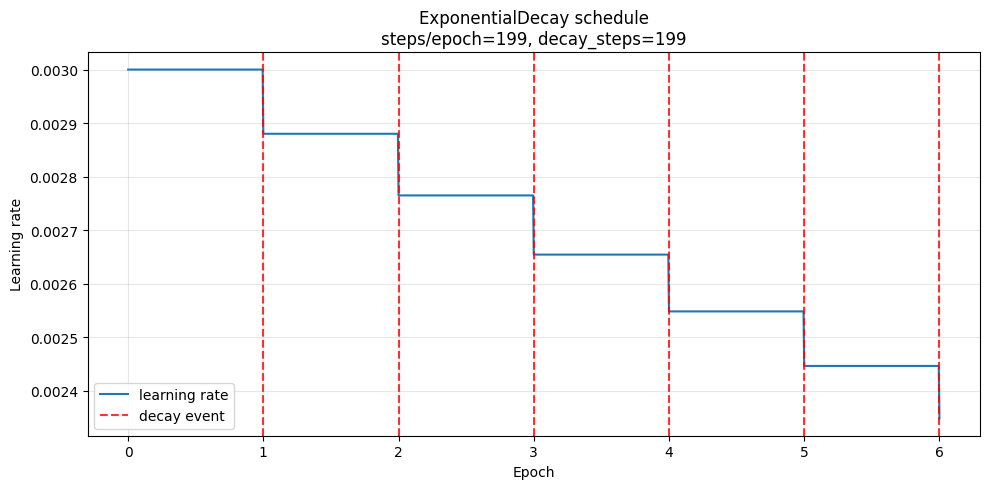

steps_per_epoch = 199
decay_steps     = 199


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_exp_decay_schedule(
    n_instances=6400,
    batch_size=32,
    initial_learning_rate=0.003,
    decay_rate=0.96,
    decay_every_epochs=1,
    n_epochs=6,
    staircase=True,
):
    """
    Plot an exponential learning-rate decay schedule and mark each decay event.

    Parameters
    ----------
    n_instances : int
        Number of training instances.
    batch_size : int
        Batch size.
    initial_learning_rate : float
        Initial learning rate.
    decay_rate : float
        Multiplicative decay factor.
    decay_every_epochs : int or float
        How many epochs between decay events.
        Example: 1 -> decay every epoch, 2 -> every 2 epochs.
    n_epochs : int
        Number of epochs to display.
    staircase : bool
        If True, use staircase decay (piecewise constant).
        If False, use smooth exponential decay.
    """
    steps_per_epoch = int(np.ceil(n_instances / batch_size))
    decay_steps = int(decay_every_epochs * steps_per_epoch)

    total_steps = n_epochs * steps_per_epoch
    steps = np.arange(total_steps + 1)

    if staircase:
        lrs = initial_learning_rate * (decay_rate ** (steps // decay_steps))
    else:
        lrs = initial_learning_rate * (decay_rate ** (steps / decay_steps))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, lrs, label="learning rate")

    # Red bars at each decay event
    decay_events = np.arange(decay_steps, total_steps + 1, decay_steps)
    for i, s in enumerate(decay_events):
        ax.axvline(
            x=s,
            color="red",
            linestyle="--",
            linewidth=1.5,
            alpha=0.8,
            label="decay event" if i == 0 else None,
        )

    # Epoch labels on a secondary x interpretation
    epoch_ticks = np.arange(0, total_steps + 1, steps_per_epoch)
    ax.set_xticks(epoch_ticks)
    ax.set_xticklabels([str(i) for i in range(len(epoch_ticks))])

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning rate")
    ax.set_title(
        f"ExponentialDecay schedule\n"
        f"steps/epoch={steps_per_epoch}, decay_steps={decay_steps}"
    )
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"steps_per_epoch = {steps_per_epoch}")
    print(f"decay_steps     = {decay_steps}")

plot_exp_decay_schedule(n_instances=6400)

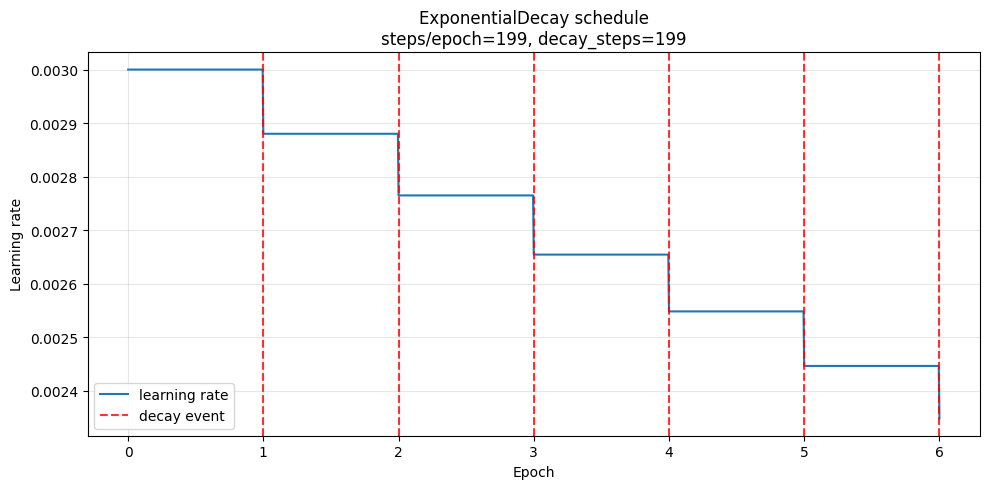

steps_per_epoch = 199
decay_steps     = 199


In [ ]:
plot_exp_decay_schedule(n_instances=6400-49)

In [ ]:
from keras.optimizers.schedules import ExponentialDecay

lookback = 49
n_hidden = 32
dropout = 0.0
patience = 5
scale = True
fit_x_transformer = True
verbose = 0
clipnorm = None
clipvalue = None

max_epochs = 4
l2_regularization = 1e-4
batch_size = 32

initial_learning_rate = 0.003

lr_schedule = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=100,      # tune this
    decay_rate=0.96,      # tune this
    staircase=True
)

#lr_schedule = 1e-03

n_runs = 3

x_transformer = preprocessor

_ = evaluate_model_over_runs(
    train_fn=train_gru,
    eval_fn=evaluate_gru,
    n_runs=n_runs,
    train_kwargs=dict(
        X=X_trainval,
        y=y_trainval,
        lookback=lookback,
        n_hidden=n_hidden,
        dropout=dropout,
        l2_regularization=l2_regularization,
        optimizer="adam",
        learning_rate=lr_schedule,   # schedule instead of float
        max_epochs=2,
        patience=patience,
        X_val=None,
        y_val=None,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
        batch_size=batch_size,
        verbose=verbose,
        clipnorm=clipnorm,
        clipvalue=clipvalue,
    ),
    eval_train_kwargs=dict(
        X=X_trainval,
        y=y_trainval,
        lookback=lookback,
        metric=rmse,
    ),
    eval_val_kwargs=dict(
        X=X_test,
        y=y_test,
        lookback=lookback,
        metric=rmse,
    ),
)


=== MODEL RUNS ===


,run,train_RMSE,val_RMSE,best_epoch
0,1,0.0766,0.0948,2
1,2,0.0758,0.0940,2
2,3,0.0785,0.0891,2



=== MODEL AVERAGE ===


,train_RMSE_mean,train_RMSE_std,val_RMSE_mean,val_RMSE_std,best_epoch_mean,best_epoch_std
0,0.0770,0.0014,0.0927,0.0031,2.00,0.00


# Macrodata

The dataset consists of quarterly U.S. macroeconomic time series. Each observation corresponds to a specific year and quarter, and includes several economic indicators.

### Variables

- **realgdp**: real Gross Domestic Product → *continuous*  
- **realcons**: real personal consumption expenditures → *continuous*  
- **realinv**: real gross private domestic investment → *continuous*  
- **realgovt**: real government consumption and investment → *continuous*  
- **realdpi**: real disposable personal income → *continuous*  
- **cpi**: consumer price index → *continuous*  
- **m1**: money stock (M1) → *continuous*  
- **tbilrate**: 3-month Treasury bill rate → *continuous*  
- **unemp**: unemployment rate → *continuous*  
- **pop**: total population → *continuous*  
- **infl**: inflation rate → *continuous*  

### Target variable

In this exercise, the target variable is:

- **infl** (inflation rate)

This variable is more volatile and less trend-dominated than other macroeconomic indicators, making it a more challenging forecasting target.

In [ ]:
import statsmodels.api as sm
import pandas as pd

# Load macrodata dataset
data = sm.datasets.macrodata.load_pandas()
df = data.data

# Create datetime index from year + quarter
df['date'] = pd.PeriodIndex(year=df['year'], quarter=df['quarter']).to_timestamp()
df = df.set_index('date')

# Drop year and quarter
df = df.drop(columns=['year', 'quarter'])

# Quick preview
print(df.shape)

(203, 12)


/tmp/ipykernel_980/2162143763.py:9: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  df['date'] = pd.PeriodIndex(year=df['year'], quarter=df['quarter']).to_timestamp()


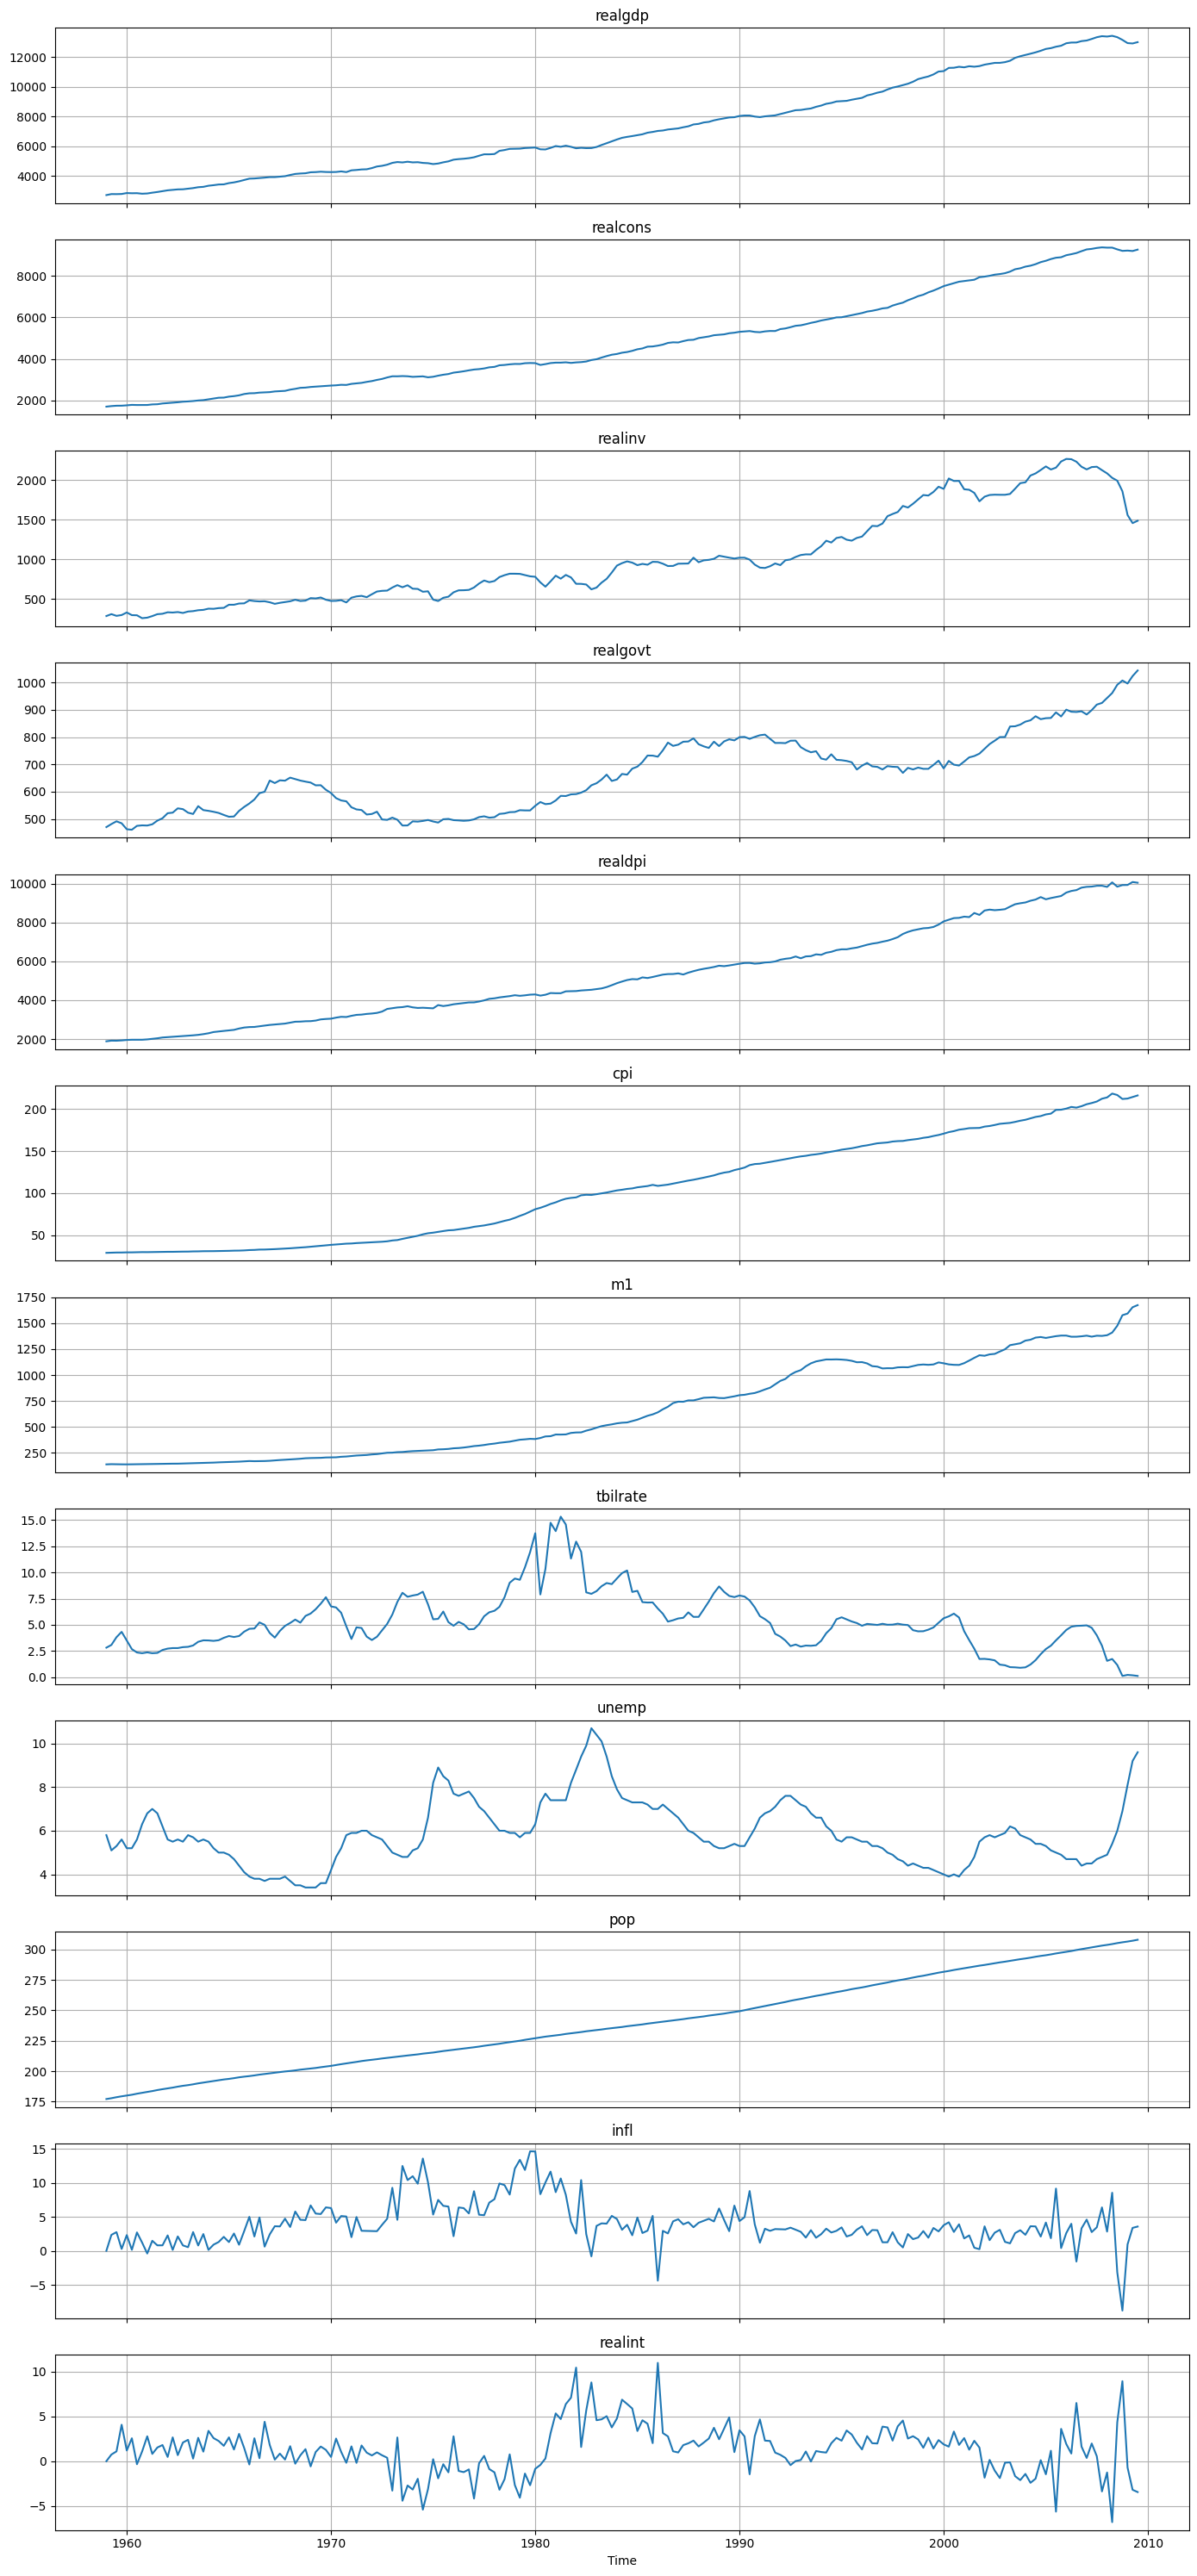

In [ ]:
# ------------------------------------------------------------
# Create grid plot (one row per variable)
# ------------------------------------------------------------
n_vars = df.shape[1]

fig, axes = plt.subplots(n_vars, 1, figsize=(14, 2.5 * n_vars), sharex=True)

# If only one variable, make axes iterable
if n_vars == 1:
    axes = [axes]

for i, col in enumerate(df.columns):
    axes[i].plot(df.index, df[col])
    axes[i].set_title(col)
    axes[i].grid(True)

plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [ ]:
y = df['infl']
X = df.drop(columns='infl')

print(X.shape, y.shape)

(203, 11) (203,)


Train: 121
Validation: 41
Test: 41


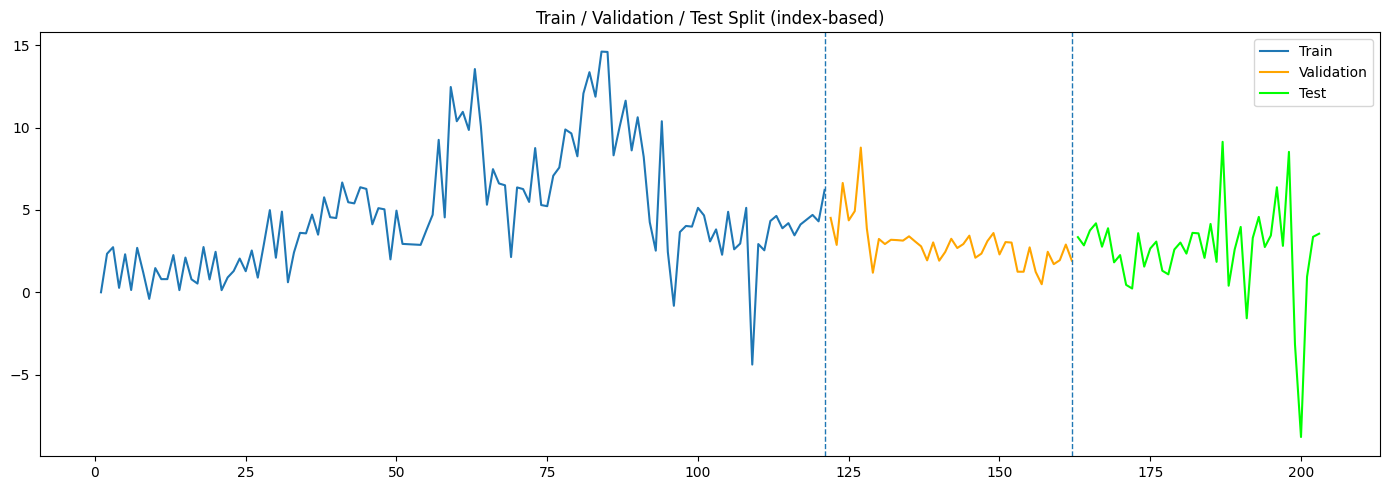

In [ ]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,   # 25% of trainval = 20% of total
    shuffle=False
)

print("Train:", len(y_train))
print("Validation:", len(y_val))
print("Test:", len(y_test))

# ------------------------------------------------------------
# Integer index: 1, 2, ..., n
# ------------------------------------------------------------
n = len(y)
idx = np.arange(1, n + 1)

n_train = len(y_train)
n_val = len(y_val)

idx_train = idx[:n_train]
idx_val = idx[n_train:n_train + n_val]
idx_test = idx[n_train + n_val:]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.plot(idx_train, y_train.values, label="Train")
plt.plot(idx_val, y_val.values, label="Validation", color="orange")
plt.plot(idx_test, y_test.values, label="Test", color="lime")

plt.axvline(n_train, linestyle="--", linewidth=1)
plt.axvline(n_train + n_val, linestyle="--", linewidth=1)

plt.title("Train / Validation / Test Split (index-based)")

plt.legend()

plt.tight_layout()
plt.show()

<a name="e4"></a>
# Exercise: The importance of being stationary

1) Try to validate the benchmarks and a GRU model on this dataset, then evaluate at least a couple of them on the test set. You should find **GRU > NN > Ridge strictly**.

Many variables are not stationary. Despite RNNs being universal approximators in theory, the training process can fail to find a good solution and is expected to struggle against non-stationarity in time series forecasting. Therefore, even deep learning models can benefit from transformation and differencing.

2) Try some methods of your choice to handle the non-stationarity of the regressors and the target, and see if this improves the performance of the best models you have found on the test set.

In [ ]:
# Your code here

**Solution**

### Ridge Regression - Validation

In [ ]:

# Fixed parameters

scale = True
x_transformer = StandardScaler()
fit_x_transformer = True

# Grid

lookback_grid = [8, 15, 22]
regularization_grid = [1e-01 * (2 ** k) for k in [0, 2, 4, 6, 8, 10]]

results = []

for lookback in lookback_grid:
    for regularization in regularization_grid:
        print(f"Running lookback={lookback}, regularization={regularization}...")

        ridge_out = train_ridge(
            X=X_train,
            y=y_train,
            regularization=regularization,
            lookback=lookback,
            scale=scale,
            x_transformer=x_transformer,
            fit_x_transformer=fit_x_transformer,
        )

        train_eval = evaluate_ridge(
            model=ridge_out["model"],
            X=X_train,
            y=y_train,
            lookback=lookback,
            metric=rmse,
            x_transformer=ridge_out["x_transformer"],
            n_total_features=ridge_out["n_total_features"],
        )

        val_eval = evaluate_ridge(
            model=ridge_out["model"],
            X=X_val,
            y=y_val,
            lookback=lookback,
            metric=rmse,
            x_transformer=ridge_out["x_transformer"],
            n_total_features=ridge_out["n_total_features"],
        )

        results.append({
            "lookback": lookback,
            "regularization": regularization,
            "train_RMSE": train_eval["metric"],
            "val_RMSE": val_eval["metric"],
        })

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
results_table = (
    pd.DataFrame(results)
    .sort_values(["val_RMSE", "lookback", "regularization"])
    .reset_index(drop=True)
)

display(
    results_table.style.highlight_min(subset=["val_RMSE"], color="lightgreen").format({
        "regularization": "{:.6g}",
        "train_RMSE": "{:.4f}",
        "val_RMSE": "{:.4f}",
    })
)

Running lookback=8, regularization=0.1...
Running lookback=8, regularization=0.4...
Running lookback=8, regularization=1.6...
Running lookback=8, regularization=6.4...
Running lookback=8, regularization=25.6...
Running lookback=8, regularization=102.4...
Running lookback=15, regularization=0.1...
Running lookback=15, regularization=0.4...
Running lookback=15, regularization=1.6...
Running lookback=15, regularization=6.4...
Running lookback=15, regularization=25.6...
Running lookback=15, regularization=102.4...
Running lookback=22, regularization=0.1...
Running lookback=22, regularization=0.4...
Running lookback=22, regularization=1.6...
Running lookback=22, regularization=6.4...
Running lookback=22, regularization=25.6...
Running lookback=22, regularization=102.4...


,lookback,regularization,train_RMSE,val_RMSE
0,8,1.6,2.0896,2.7986
1,8,0.4,2.3663,3.0112
2,8,6.4,1.9464,3.6887
3,8,25.6,1.8921,4.4234
4,15,25.6,1.9275,4.8997
5,8,102.4,1.9401,4.9064
6,15,102.4,1.9676,5.0254
7,15,6.4,2.0570,5.3753
8,8,0.1,3.0786,5.6571
9,15,1.6,2.2568,6.3543


### Ridge Regression Re-Train and Test Evaluation

In [ ]:


# ------------------------------------------------------------
# Fixed preprocessing parameters
# ------------------------------------------------------------
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True

# ------------------------------------------------------------
# Best parameters (replace with your selected values)
# ------------------------------------------------------------

best_lookback = 8
best_regularization = 1e-03 * (2 ** 4)


ridge_out = train_ridge(
    X=X_train,
    y=y_train,
    regularization=best_regularization,
    lookback=best_lookback,
    scale=scale,
    x_transformer=x_transformer,
    fit_x_transformer=fit_x_transformer,
)

train_eval = evaluate_ridge(
    model=ridge_out["model"],
    X=X_train,
    y=y_train,
    lookback=best_lookback,
    metric=rmse,
    x_transformer=ridge_out["x_transformer"],
    n_total_features=ridge_out["n_total_features"],
)

test_eval = evaluate_ridge(
    model=ridge_out["model"],
    X=X_test,
    y=y_test,
    lookback=best_lookback,
    metric=rmse,
    x_transformer=ridge_out["x_transformer"],
    n_total_features=ridge_out["n_total_features"],
)

results_table = pd.DataFrame([{
    "train_RMSE": train_eval["metric"],
    "test_RMSE": test_eval["metric"],
}])

display(
    results_table.style.format({
        "train_RMSE": "{:.4f}",
        "test_RMSE": "{:.4f}",
    })
)

,train_RMSE,test_RMSE
0,5.7865,25.7446


### NN Validation

In [ ]:
# Fixed parameters
lookback = 8
n_hidden = 16
dropout = 0.
l2_regularization = 0.0
optimizer = "rmsprop"
max_epochs = 1000
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
verbose = 0
clipnorm = None
clipvalue = None

# Grid
learning_rate_grid = [1e-04, 5e-04, 1e-04, 5e-3]
batch_size_grid = [8, 16, 32]

results = []

for learning_rate in learning_rate_grid:
    for batch_size in batch_size_grid:
        print(f"Running learning_rate={learning_rate}, batch_size={batch_size}...")

        nn_out = train_nn(
            X=X_train,
            y=y_train,
            lookback=lookback,
            n_hidden=n_hidden,
            dropout=dropout,
            l2_regularization=l2_regularization,
            optimizer=optimizer,
            learning_rate=learning_rate,
            max_epochs=max_epochs,
            patience=patience,
            X_val=X_val,
            y_val=y_val,
            scale=scale,
            x_transformer=x_transformer,
            fit_x_transformer=fit_x_transformer,
            batch_size=batch_size,
            verbose=verbose,
            clipnorm=clipnorm,
            clipvalue=clipvalue,
        )

        train_eval = evaluate_nn(
            model=nn_out["model"],
            X=X_train,
            y=y_train,
            lookback=lookback,
            metric=rmse,
            x_transformer=nn_out["x_transformer"],
            n_total_features=nn_out["n_total_features"],
        )

        val_eval = evaluate_nn(
            model=nn_out["model"],
            X=X_val,
            y=y_val,
            lookback=lookback,
            metric=rmse,
            x_transformer=nn_out["x_transformer"],
            n_total_features=nn_out["n_total_features"],
        )

        results.append({
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "best_epoch": nn_out["best_epoch"],
            "train_RMSE": train_eval["metric"],
            "val_RMSE": val_eval["metric"],
        })

results_table = (
    pd.DataFrame(results)
    .sort_values(["learning_rate", "batch_size"])
    .reset_index(drop=True)
)

display(
    results_table.style
    .highlight_min(subset=["val_RMSE"], color="lightgreen")
    .format({
        "learning_rate": "{:.0e}",
        "batch_size": "{:.0f}",
        "best_epoch": "{:.0f}",
        "train_RMSE": "{:.4f}",
        "val_RMSE": "{:.4f}",
    })
)

Running learning_rate=0.0001, batch_size=8...
Running learning_rate=0.0001, batch_size=16...


Running learning_rate=0.0001, batch_size=32...


Running learning_rate=0.0005, batch_size=8...
Running learning_rate=0.0005, batch_size=16...
Running learning_rate=0.0005, batch_size=32...
Running learning_rate=0.0001, batch_size=8...
Running learning_rate=0.0001, batch_size=16...
Running learning_rate=0.0001, batch_size=32...
Running learning_rate=0.005, batch_size=8...
Running learning_rate=0.005, batch_size=16...
Running learning_rate=0.005, batch_size=32...


,learning_rate,batch_size,best_epoch,train_RMSE,val_RMSE
0,1e-04,8,6,3.6223,1.9998
1,1e-04,8,22,3.6585,1.4781
2,1e-04,16,6,2.8153,2.8119
3,1e-04,16,4,3.0952,3.0236
4,1e-04,32,12,3.2845,1.9259
5,1e-04,32,66,2.3281,5.6779
6,5e-04,8,3,2.9247,2.3570
7,5e-04,16,8,2.4187,1.1886
8,5e-04,32,18,1.9551,7.6703
9,5e-03,8,5,3.0725,4.5400


In [ ]:
# Fixed parameters
lookback = 8
n_hidden = 16
dropout = 0.
l2_regularization = 0.0
optimizer = "rmsprop"
max_epochs = 8
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
verbose = 0
clipnorm = None
clipvalue = None

# Grid
learning_rate_grid = 5e-04
batch_size_grid = 32


import numpy as np

n_runs = 8
results = []

for run in range(n_runs):
    print(f"Run {run+1}/{n_runs}")

    # ------------------------------------------------------------
    # Train
    # ------------------------------------------------------------
    nn_out = train_nn(
        X=X_train,
        y=y_train,
        lookback=lookback,
        n_hidden=n_hidden,
        dropout=dropout,
        l2_regularization=l2_regularization,
        optimizer=optimizer,
        learning_rate=learning_rate,
        max_epochs=max_epochs,
        patience=patience,
        X_val=None,
        y_val=None,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
        batch_size=batch_size,
        verbose=verbose,
        clipnorm=clipnorm,
        clipvalue=clipvalue,
    )

    # ------------------------------------------------------------
    # Evaluate
    # ------------------------------------------------------------
    train_eval = evaluate_nn(
        model=nn_out["model"],
        X=X_train,
        y=y_train,
        lookback=lookback,
        metric=rmse,
        x_transformer=nn_out["x_transformer"],
        n_total_features=nn_out["n_total_features"],
    )

    test_eval = evaluate_nn(
        model=nn_out["model"],
        X=X_test,
        y=y_test,
        lookback=lookback,
        metric=rmse,
        x_transformer=nn_out["x_transformer"],
        n_total_features=nn_out["n_total_features"],
    )

    results.append({
        "train_RMSE": train_eval["metric"],
        "test_RMSE": test_eval["metric"],
    })

# ------------------------------------------------------------
# Aggregate results
# ------------------------------------------------------------
results_df = pd.DataFrame(results)

summary = pd.DataFrame([{
    "train_mean": results_df["train_RMSE"].mean(),
    "train_std": results_df["train_RMSE"].std(),
    "test_mean": results_df["test_RMSE"].mean(),
    "test_std": results_df["test_RMSE"].std(),
}])

display(
    summary.style.format("{:.4f}")
)

Run 1/8
Run 2/8
Run 3/8
Run 4/8
Run 5/8
Run 6/8
Run 7/8
Run 8/8


,train_mean,train_std,test_mean,test_std
0,2.2511,0.3892,9.1689,4.5264


# GRU Validation

Running n_hidden=8, dropout=0.0...
Running n_hidden=8, dropout=0.1...
Running n_hidden=8, dropout=0.2...
Running n_hidden=8, dropout=0.3...
Running n_hidden=16, dropout=0.0...
Running n_hidden=16, dropout=0.1...
Running n_hidden=16, dropout=0.2...
Running n_hidden=16, dropout=0.3...
Running n_hidden=32, dropout=0.0...
Running n_hidden=32, dropout=0.1...
Running n_hidden=32, dropout=0.2...
Running n_hidden=32, dropout=0.3...
Running n_hidden=64, dropout=0.0...
Running n_hidden=64, dropout=0.1...
Running n_hidden=64, dropout=0.2...
Running n_hidden=64, dropout=0.3...


,n_hidden,dropout,best_epoch,train_RMSE,val_RMSE,time_seconds
0,16,0.2,8,1.6906,1.1634,2.58
1,64,0.2,11,1.8545,1.2344,2.87
2,8,0.3,32,1.7835,1.2830,6.90
3,64,0.1,5,2.0885,1.2909,2.23
4,8,0.2,7,1.7811,1.3535,2.40
5,32,0.2,11,2.2686,1.3648,2.86
6,32,0.3,2,2.1046,1.3879,1.91
7,64,0.3,11,2.2289,1.3967,2.84
8,32,0.1,4,1.8408,1.4804,2.16
9,16,0.1,8,1.8218,1.5215,2.63


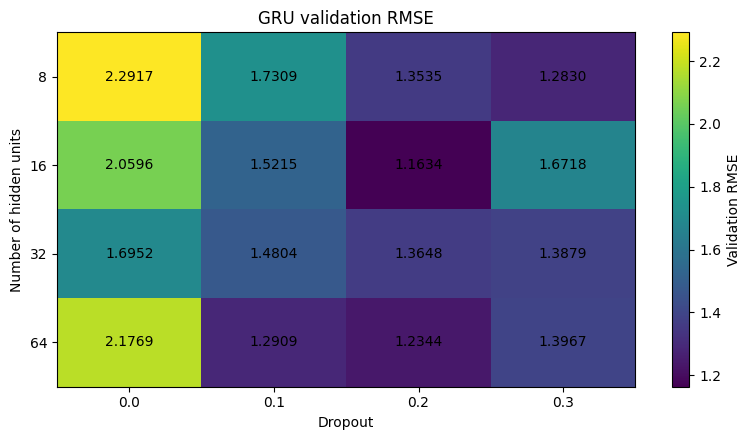

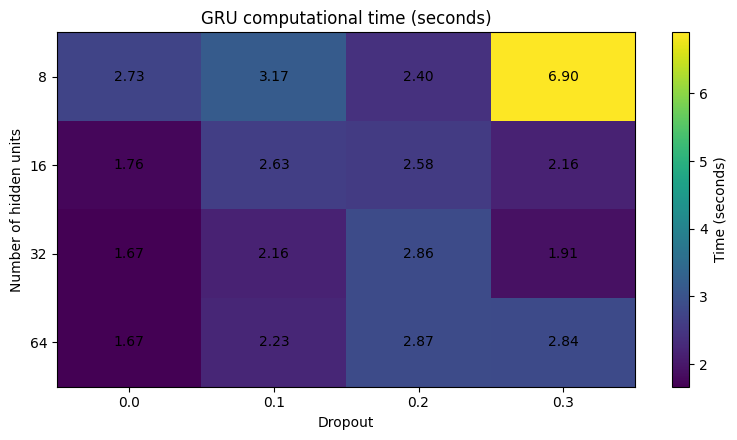

In [ ]:
results = []

# ------------------------------------------------------------
# Fixed parameters
# ------------------------------------------------------------
lookback = 8
learning_rate_grid = 5e-04
batch_size_grid = 32
recurrent_dropout = 0.0
l2_regularization = 0.0
optimizer = "rmsprop"
max_epochs = 1000
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
verbose = 0
clipnorm = None
clipvalue = None

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
n_hidden_grid = [8, 16, 32, 64]
dropout_grid = [0.0, 0.1, 0.2, 0.3]

for n_hidden in n_hidden_grid:
    for dropout in dropout_grid:
        print(f"Running n_hidden={n_hidden}, dropout={dropout:.1f}...")

        start_time = time.perf_counter()

        gru_out = train_gru(
            X=X_train,
            y=y_train,
            lookback=lookback,
            n_hidden=n_hidden,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            l2_regularization=l2_regularization,
            optimizer=optimizer,
            learning_rate=learning_rate,
            max_epochs=max_epochs,
            patience=patience,
            X_val=X_val,
            y_val=y_val,
            scale=scale,
            x_transformer=x_transformer,
            fit_x_transformer=fit_x_transformer,
            batch_size=batch_size,
            verbose=verbose,
            clipnorm=clipnorm,
            clipvalue=clipvalue,
        )

        elapsed_time = time.perf_counter() - start_time

        train_eval = evaluate_gru(
            model=gru_out["model"],
            X=X_train,
            y=y_train,
            lookback=lookback,
            metric=rmse,
            x_transformer=gru_out["x_transformer"],
            n_total_features=gru_out["n_total_features"],
        )

        val_eval = evaluate_gru(
            model=gru_out["model"],
            X=X_val,
            y=y_val,
            lookback=lookback,
            metric=rmse,
            x_transformer=gru_out["x_transformer"],
            n_total_features=gru_out["n_total_features"],
        )

        results.append({
            "n_hidden": n_hidden,
            "dropout": dropout,
            "best_epoch": gru_out["best_epoch"],
            "train_RMSE": train_eval["metric"],
            "val_RMSE": val_eval["metric"],
            "time_seconds": elapsed_time,
        })

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
results_table = (
    pd.DataFrame(results)
    .sort_values(["val_RMSE", "n_hidden", "dropout"])
    .reset_index(drop=True)
)

display(
    results_table.style.highlight_min(subset=["val_RMSE"], color="lightgreen").format({
        "dropout": "{:.1f}",
        "best_epoch": "{:.0f}",
        "train_RMSE": "{:.4f}",
        "val_RMSE": "{:.4f}",
        "time_seconds": "{:.2f}",
    })
)

# ------------------------------------------------------------
# Heatmap: validation RMSE
# ------------------------------------------------------------
metric_heatmap_df = results_table.pivot(
    index="n_hidden",
    columns="dropout",
    values="val_RMSE"
)

metric_heatmap_df = metric_heatmap_df[dropout_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(metric_heatmap_df.values, aspect="auto")

ax.set_xticks(np.arange(len(metric_heatmap_df.columns)))
ax.set_yticks(np.arange(len(metric_heatmap_df.index)))
ax.set_xticklabels([f"{d:.1f}" for d in metric_heatmap_df.columns])
ax.set_yticklabels(metric_heatmap_df.index)

ax.set_xlabel("Dropout")
ax.set_ylabel("Number of hidden units")
ax.set_title("GRU validation RMSE")

for i in range(metric_heatmap_df.shape[0]):
    for j in range(metric_heatmap_df.shape[1]):
        value = metric_heatmap_df.iloc[i, j]
        ax.text(j, i, f"{value:.4f}", ha="center", va="center")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Validation RMSE")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Heatmap: computational time
# ------------------------------------------------------------
time_heatmap_df = results_table.pivot(
    index="n_hidden",
    columns="dropout",
    values="time_seconds"
)

time_heatmap_df = time_heatmap_df[dropout_grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(time_heatmap_df.values, aspect="auto")

ax.set_xticks(np.arange(len(time_heatmap_df.columns)))
ax.set_yticks(np.arange(len(time_heatmap_df.index)))
ax.set_xticklabels([f"{d:.1f}" for d in time_heatmap_df.columns])
ax.set_yticklabels(time_heatmap_df.index)

ax.set_xlabel("Dropout")
ax.set_ylabel("Number of hidden units")
ax.set_title("GRU computational time (seconds)")

for i in range(time_heatmap_df.shape[0]):
    for j in range(time_heatmap_df.shape[1]):
        value = time_heatmap_df.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Time (seconds)")

plt.tight_layout()
plt.show()

In [ ]:
lookback = 8
learning_rate_grid = 5e-04
batch_size_grid = 32
dropout = 0.3
recurrent_dropout = 0.0
l2_regularization = 0.0
optimizer = "rmsprop"
max_epochs = 21
patience = 5
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True
verbose = 0
clipnorm = None
clipvalue = None
n_hidden = 64


n_runs = 8
results = []

for run in range(n_runs):
    print(f"Run {run+1}/{n_runs}")

    gru_out = train_gru(
        X=X_train,
        y=y_train,
        lookback=lookback,
        n_hidden=n_hidden,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout,
        l2_regularization=l2_regularization,
        optimizer=optimizer,
        learning_rate=learning_rate,
        max_epochs=max_epochs,
        patience=patience,
        X_val=None,
        y_val=None,
        scale=scale,
        x_transformer=x_transformer,
        fit_x_transformer=fit_x_transformer,
        batch_size=batch_size,
        verbose=verbose,
        clipnorm=clipnorm,
        clipvalue=clipvalue,
    )

    gru_train_eval = evaluate_gru(
        model=gru_out["model"],
        X=X_train,
        y=y_train,
        lookback=lookback,
        metric=rmse,
        x_transformer=gru_out["x_transformer"],
        n_total_features=gru_out["n_total_features"],
    )

    gru_val_eval = evaluate_gru(
        model=gru_out["model"],
        X=X_val,
        y=y_val,
        lookback=lookback,
        metric=rmse,
        x_transformer=gru_out["x_transformer"],
        n_total_features=gru_out["n_total_features"],
    )

    gru_test_eval = evaluate_gru(
        model=gru_out["model"],
        X=X_test,
        y=y_test,
        lookback=lookback,
        metric=rmse,
        x_transformer=gru_out["x_transformer"],
        n_total_features=gru_out["n_total_features"],
    )

    results.append({
        "train_RMSE": gru_train_eval["metric"],
        "val_RMSE": gru_val_eval["metric"],
        "test_RMSE": gru_test_eval["metric"],
    })

# ------------------------------------------------------------
# Aggregate results
# ------------------------------------------------------------
results_df = pd.DataFrame(results)

summary = pd.DataFrame([{
    "train_mean": results_df["train_RMSE"].mean(),
    "train_std": results_df["train_RMSE"].std(),
    "val_mean": results_df["val_RMSE"].mean(),
    "val_std": results_df["val_RMSE"].std(),
    "test_mean": results_df["test_RMSE"].mean(),
    "test_std": results_df["test_RMSE"].std(),
}])

display(summary.style.format("{:.4f}"))

Run 1/8
Run 2/8
Run 3/8
Run 4/8
Run 5/8
Run 6/8
Run 7/8
Run 8/8


,train_mean,train_std,val_mean,val_std,test_mean,test_std
0,1.9687,0.2078,2.1171,0.4952,3.2528,0.2673


In [ ]:
from statsmodels.tsa.stattools import adfuller

def need_differiencing(series, alpha=0.05):
    """
    Returns True if the series is NOT stationary (i.e., needs differencing),
    based on the Augmented Dickey-Fuller test.

    Parameters
    ----------
    series : array-like (pd.Series recommended)
    alpha : significance level (default 0.05)

    Returns
    -------
    bool : True if non-stationary, False if stationary
    """

    # Drop NaNs just in case
    series = series.dropna()

    result = adfuller(series)
    p_value = result[1]

    # If p-value > alpha → fail to reject null → non-stationary
    return p_value >= alpha

In [ ]:
need_differiencing(y)

np.False_

In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline



class ConditionalDifferencer(BaseEstimator, TransformerMixin):
    """
    Column-wise conditional differencing transformer.

    For each column:
    - run ADF test
    - if non-stationary, apply first difference
    - pad the first value with 0
    - store the initial value for inverse transform

    Inverse transform uses finite integration:
    x_t = x_0 + sum_{k=1..t} diff_k
    """

    def __init__(self, alpha=-1.):
        self.alpha = alpha

    def fit(self, X, y=None):
        X_df = self._to_dataframe(X)

        self.feature_names_in_ = list(X_df.columns)
        self.need_diff_ = {}
        self.initial_values_ = {}

        for col in X_df.columns:
            s = X_df[col]
            self.need_diff_[col] = need_differiencing(s, alpha=self.alpha)
            self.initial_values_[col] = float(s.iloc[0])

        return self

    def transform(self, X):
        X_df = self._to_dataframe(X)
        X_out = X_df.copy()

        for col in X_df.columns:
            if self.need_diff_.get(col, False):
                values = X_df[col].to_numpy(dtype=float)
                diffed = np.diff(values, n=1)
                diffed = np.insert(diffed, 0, 0.0)  # pad first element with 0
                X_out[col] = diffed

        return X_out.to_numpy()

    def inverse_transform(self, X):
        X_df = self._to_dataframe(X, columns=self.feature_names_in_)
        X_out = X_df.copy()

        for col in X_df.columns:
            if self.need_diff_.get(col, False):
                diffed = X_df[col].to_numpy(dtype=float)
                x0 = self.initial_values_[col]
                restored = x0 + np.cumsum(diffed)
                X_out[col] = restored

        return X_out.to_numpy()

    def _to_dataframe(self, X, columns=None):
        if isinstance(X, pd.DataFrame):
            return X.copy()

        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        if columns is None:
            if hasattr(self, "feature_names_in_"):
                columns = self.feature_names_in_
            else:
                columns = [f"x{i}" for i in range(X.shape[1])]

        return pd.DataFrame(X, columns=columns)

In [ ]:
preprocessor = Pipeline([
    ("conditional_diff", ConditionalDifferencer(alpha=0.05)),
    ("scaler", StandardScaler())
])



# ------------------------------------------------------------
# Fixed preprocessing parameters
# ------------------------------------------------------------
scale = True
x_transformer = StandardScaler()
fit_x_transformer = True

# ------------------------------------------------------------
# Best parameters (replace with your selected values)
# ------------------------------------------------------------

best_lookback = 8
best_regularization = 1e-03 * (2 ** 4)


ridge_out = train_ridge(
    X=X_train,
    y=y_train,
    regularization=best_regularization,
    lookback=best_lookback,
    scale=scale,
    x_transformer=preprocessor,
    fit_x_transformer=fit_x_transformer,
)

train_eval = evaluate_ridge(
    model=ridge_out["model"],
    X=X_train,
    y=y_train,
    lookback=best_lookback,
    metric=rmse,
    x_transformer=ridge_out["x_transformer"],
    n_total_features=ridge_out["n_total_features"],
)

test_eval = evaluate_ridge(
    model=ridge_out["model"],
    X=X_test,
    y=y_test,
    lookback=best_lookback,
    metric=rmse,
    x_transformer=ridge_out["x_transformer"],
    n_total_features=ridge_out["n_total_features"],
)

results_table = pd.DataFrame([{
    "train_RMSE": train_eval["metric"],
    "test_RMSE": test_eval["metric"],
}])

display(
    results_table.style.format({
        "train_RMSE": "{:.4f}",
        "test_RMSE": "{:.4f}",
    })
)

,train_RMSE,test_RMSE
0,12.7789,39.6074


In [ ]:
# Fixed parameters
lookback = 8
n_hidden = 16
dropout = 0.
l2_regularization = 0.0
optimizer = "rmsprop"
max_epochs = 18
patience = 5
scale = True
x_transformer = preprocessor
fit_x_transformer = True
verbose = 0
clipnorm = None
clipvalue = None

# Grid
learning_rate_grid = 1e-04
batch_size_grid = 8

# Recreate preprocessor each time (important: avoid leakage / state reuse)
preprocessor = Pipeline([
        ("conditional_diff", ConditionalDifferencer(alpha=0.05)),
        ("scaler", StandardScaler())
    ])


n_runs = 8
results = []

for run in range(n_runs):
    print(f"Run {run+1}/{n_runs}")

    # ------------------------------------------------------------
    # Train
    # ------------------------------------------------------------
    nn_out = train_nn(
        X=X_train,
        y=y_train,
        lookback=lookback,
        n_hidden=n_hidden,
        dropout=dropout,
        l2_regularization=l2_regularization,
        optimizer=optimizer,
        learning_rate=learning_rate,
        max_epochs=max_epochs,
        patience=patience,
        X_val=None,
        y_val=None,
        scale=scale,
        x_transformer=preprocessor,
        fit_x_transformer=True,
        batch_size=batch_size,
        verbose=verbose,
        clipnorm=clipnorm,
        clipvalue=clipvalue,
    )

    # ------------------------------------------------------------
    # Evaluate
    # ------------------------------------------------------------
    train_eval = evaluate_nn(
        model=nn_out["model"],
        X=X_train,
        y=y_train,
        lookback=lookback,
        metric=rmse,
        x_transformer=nn_out["x_transformer"],
        n_total_features=nn_out["n_total_features"],
    )

    test_eval = evaluate_nn(
        model=nn_out["model"],
        X=X_test,
        y=y_test,
        lookback=lookback,
        metric=rmse,
        x_transformer=nn_out["x_transformer"],
        n_total_features=nn_out["n_total_features"],
    )

    results.append({
        "train_RMSE": train_eval["metric"],
        "test_RMSE": test_eval["metric"],
    })

# ------------------------------------------------------------
# Aggregate results
# ------------------------------------------------------------
results_df = pd.DataFrame(results)

summary = pd.DataFrame([{
    "train_mean": results_df["train_RMSE"].mean(),
    "train_std": results_df["train_RMSE"].std(),
    "test_mean": results_df["test_RMSE"].mean(),
    "test_std": results_df["test_RMSE"].std(),
}])

display(summary.style.format("{:.4f}"))

Run 1/8
Run 2/8
Run 3/8
Run 4/8
Run 5/8
Run 6/8
Run 7/8
Run 8/8


,train_mean,train_std,test_mean,test_std
0,8.7984,5.2373,21.9995,6.4583


In [ ]:
preprocessor = Pipeline([
    ("conditional_diff", ConditionalDifferencer(alpha=0.05)),
    ("scaler", StandardScaler())
])


lookback = 8
batch_size = 16
learning_rate = 1e-4
dropout = 0.2
recurrent_dropout = 0.0
l2_regularization = 0.0
optimizer = "rmsprop"
max_epochs = 20
patience = 5
scale = True
x_transformer = preprocessor
fit_x_transformer = True
verbose = 0
clipnorm = None
clipvalue = None

n_runs = 8
results = []

for run in range(n_runs):
    print(f"Run {run+1}/{n_runs}")


    # ------------------------------------------------------------
    # Train
    # ------------------------------------------------------------
    gru_out = train_gru(
        X=X_train,
        y=y_train,
        lookback=lookback,
        n_hidden=n_hidden,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout,
        l2_regularization=l2_regularization,
        optimizer=optimizer,
        learning_rate=learning_rate,
        max_epochs=max_epochs,
        patience=patience,
        X_val=X_val,
        y_val=y_val,
        scale=scale,
        x_transformer=preprocessor,
        fit_x_transformer=True,
        batch_size=batch_size,
        verbose=verbose,
        clipnorm=clipnorm,
        clipvalue=clipvalue,
    )

    # ------------------------------------------------------------
    # Evaluate
    # ------------------------------------------------------------
    gru_train_eval = evaluate_gru(
        model=gru_out["model"],
        X=X_train,
        y=y_train,
        lookback=lookback,
        metric=rmse,
        x_transformer=gru_out["x_transformer"],
        n_total_features=gru_out["n_total_features"],
    )

    gru_val_eval = evaluate_gru(
        model=gru_out["model"],
        X=X_val,
        y=y_val,
        lookback=lookback,
        metric=rmse,
        x_transformer=gru_out["x_transformer"],
        n_total_features=gru_out["n_total_features"],
    )

    gru_test_eval = evaluate_gru(
        model=gru_out["model"],
        X=X_test,
        y=y_test,
        lookback=lookback,
        metric=rmse,
        x_transformer=gru_out["x_transformer"],
        n_total_features=gru_out["n_total_features"],
    )

    results.append({
        "train_RMSE": gru_train_eval["metric"],
        "val_RMSE": gru_val_eval["metric"],
        "test_RMSE": gru_test_eval["metric"],
    })

# ------------------------------------------------------------
# Aggregate results
# ------------------------------------------------------------
results_df = pd.DataFrame(results)

summary = pd.DataFrame([{
    "train_mean": results_df["train_RMSE"].mean(),
    "train_std": results_df["train_RMSE"].std(),
    "val_mean": results_df["val_RMSE"].mean(),
    "val_std": results_df["val_RMSE"].std(),
    "test_mean": results_df["test_RMSE"].mean(),
    "test_std": results_df["test_RMSE"].std(),
}])

display(summary.style.format("{:.4f}"))

Run 1/8
Run 2/8
Run 3/8
Run 4/8
Run 5/8
Run 6/8
Run 7/8
Run 8/8


,train_mean,train_std,val_mean,val_std,test_mean,test_std
0,15.0021,7.9199,23.4747,16.0701,12.3233,7.4806
